# FINAL_RESULTS_cov10_p80 — 80-cactus-founder control, arch decomposition

**What this notebook evaluates.** AF estimation on simulated cov10 pools (Chr1 only) on the **p80** panel: 80 cactus founders (all long-read assemblies), built via the arch-decomposition pipeline (annotate_vcf + convert-to-biallelic). Methods: `cactus_em global` and `cactus_em ★★` (window 10kb + λ=0.3 + smooth 5α0.5).

**Regime matrix (6 cells)**:
| | g=0 (no recomb) | g=1 (1 gen recomb) | g=3 (3 gen recomb) |
|---|---|---|---|
| n=50 (subset) | `n50_g0` | `n50_g1` | `n50_g3` |
| n=231 ("perfect mix") | `n231_g0` | `n231_g1` | — |
| n=50 + dominant individual | — | — | `n50_g3_dom500` (selection-like) |

**Context vs the deleted p82 control.** p82 used vcfbub + `bcftools norm -m -any`. p80 uses arch decomposition (`annotate_vcf` → `convert-to-biallelic`) on the 135-asm-graph A1 catalog. Sample drop: 5772 (Set-1 mislabel) + 9947 (Ped-0 low cov). PG-index reused from production `pang_135_pangenie_index` (graph-consistent with the catalog).

**Join key**: canonical `(chrom, pos, ref, alt)` via `cn_var_p80.meta.npz` — never join on length-only (memory: `feedback_freqk_parser_full_key`).

**Primary metric**: MAE (memory: `feedback_use_mae_not_r2`). R² stays >0.99 even when bias is visible; MAE is what GEA consumes.


## ⚠️ Simulation validation — raw-assembly reads vs VCF-consensus reads (g0)

**Read this first.** Every result in this notebook is computed from reads simulated off **VCF-consensus** founder FASTAs (`bcftools consensus` of the panel VCF on TAIR10), pooled with VISOR. Those reads contain *only* variants the panel VCF encoded — and `cn_full` (the EM's k-mer dictionary) is built from that same VCF — so the read substrate is a guaranteed subset of the estimator's k-mers. Real pool-seq reads are not: real genomes carry variation and repeat content the pangenome graph never captured. To confirm this isn't flattering the estimator, we re-simulated the two **g0** regimes **directly from the raw long-read assemblies** (`…/pang_1001gplus/…/chr_only/<asm_id>.chr.fa`, via `pywgsim`, bypassing the VCF→consensus→VISOR path) and re-ran `cactus_em global` against the **same** `cn_full` / `cn_var` / truth. *Only the read source differs.*

**Result: for g0, raw-assembly and VCF-consensus reads give the same answer.**

`n50_g0` — 50 individuals, 30/80 founders represented:

| class | MAE cons | MAE raw | RMSE cons | RMSE raw | R² cons | R² raw | \|d\|>0.1 raw |
|---|---|---|---|---|---|---|---|
| ALL   | 0.0048 | 0.0055 | 0.0081 | 0.0093 | 0.9985 | 0.9980 | 0.0006 |
| SNP   | 0.0049 | 0.0055 | 0.0081 | 0.0094 | 0.9985 | 0.9981 | 0.0006 |
| indel | 0.0048 | 0.0054 | 0.0080 | 0.0091 | 0.9983 | 0.9977 | 0.0006 |
| SV    | 0.0028 | 0.0035 | 0.0053 | 0.0081 | 0.9983 | 0.9961 | 0.0012 |

`n231_g0` — "perfect mix", 231 individuals, 72/80 founders represented:

| class | MAE cons | MAE raw | RMSE cons | RMSE raw | R² cons | R² raw | \|d\|>0.1 raw |
|---|---|---|---|---|---|---|---|
| ALL   | 0.0048 | 0.0047 | 0.0077 | 0.0080 | 0.9986 | 0.9984 | 0.0008 |
| SNP   | 0.0048 | 0.0047 | 0.0077 | 0.0081 | 0.9986 | 0.9985 | 0.0008 |
| indel | 0.0048 | 0.0047 | 0.0076 | 0.0079 | 0.9983 | 0.9982 | 0.0008 |
| SV    | 0.0030 | 0.0033 | 0.0057 | 0.0076 | 0.9980 | 0.9964 | 0.0014 |

Both substrates used the same 10× read budget (verified: 9.95× consensus / 10.00× raw of TAIR10 Chr1). The EM's `λ̂` coverage estimate is ~7.2× (raw) vs ~7.6× (consensus) from that identical budget — a uniform-h/partly-represented-panel artifact present for *both* substrates, not missing depth; the raw-vs-consensus gap (~5%) is the extra off-panel k-mer mass real assemblies carry. Despite that, **ALL-class MAE is within ±0.0007 and R² within 0.0005** at both pool sizes (at the production-relevant n231 "perfect mix", raw is in fact marginally better: MAE 0.0047 vs 0.0048). The only visible cost of the honest substrate is a tiny new outlier tail (≤0.08% of records, vs exactly 0 for consensus) and a proportionally larger but still small SV-RMSE penalty.

**Conclusion → the regime sweep below keeps the VCF-consensus simulation.** For **g0** it is validated against the open read substrate. For the **recombinant regimes (g1, g3, dom500)** the VCF-consensus path is *required*: a recombinant mosaic's breakpoints are in **TAIR10 coordinates** (LD-block boundaries), and consensus FASTAs are already in TAIR10 coordinates so a mosaic is stitched by a trivial slice; raw assemblies are in their own frame (Chr1 = 29.5–34.6 Mb vs TAIR10's 30.4 Mb), so stitching from raw sequence needs an assembly→TAIR10 alignment (minimap2) and a per-breakpoint approximation. Since g0 shows the read substrate is *not* the accuracy bottleneck, that machinery buys nothing — so consensus reads are the right call. Full rationale + numbers in `docs/SIMULATIONS_METHODS.md` §3.1.

*Caveat: this isolates the **read substrate** only — truth is still computed through `cn_var` (closed-loop on truth). An independent alignment-based truth would be needed to test `cn_var` correctness; out of scope here. Validation reads under `benchmarks/p80/sims_raw/`; comparison tool `benchmarks/p80/scripts/compare_af_vs_truth.py`.*


In [1]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from pathlib import Path

ROOT = Path('/global/scratch/users/tbellg/kmate/benchmarks/p80')
RESULTS = ROOT / 'results'
SIMS = ROOT / 'sims'
DATA = ROOT / 'data'
PLOTS = RESULTS / 'plots'
PLOTS.mkdir(parents=True, exist_ok=True)

GREY = '#888888'

# Method display names — friendlier than 'global' / 'star2'
METHOD_LABELS = {
    'global': 'h chromosome',
    'star2':  'h 10kb window',
}

# Full p80 regime sweep — 3 pool sizes × 3 recomb levels (mostly) + 1 selection variant.
# Ordering chosen so that within-row comparisons are useful (small→large, then more recomb).
# Ordered easiest → hardest based on headline MAE on realized-pool truth.
REGIMES = ['n80_g0', 'n50_g0', 'n80_g1', 'n50_g1', 'n50_g3', 'n50_g3_dom500']
METHODS = ['global', 'star2']  # 'star2' = the ★★ window+smooth recipe

# Truth-file location varies for the skewed regime (different dir-name tag).
# Map regime -> sim-dir subfolder name.
REGIME_SIMDIR = {
    'n50_g0':         'cov10_n50_g0_s42_hotspots_p80_chr1',
    'n50_g1':         'cov10_n50_g1_s42_hotspots_p80_chr1',
    'n50_g3':         'cov10_n50_g3_s42_hotspots_p80_chr1',
    'n80_g0':        'cov10_n80_g0_s42_hotspots_p80_chr1',
    'n80_g1':        'cov10_n80_g1_s42_hotspots_p80_chr1',
    'n50_g3_dom500':  'cov10_n50_g3_s42_hotspots_dom500_p80_chr1',
    'n231_g0':       'cov10_n231_g0_s42_hotspots_p80_chr1',
}


def density_scatter(ax, x, y, nbins=80, s=4, cmap='viridis', alpha=0.7, subsample=None, rng=42):
    """Scatter colored by 2D-histogram local density."""
    x = np.asarray(x); y = np.asarray(y)
    finite = np.isfinite(x) & np.isfinite(y)
    x = x[finite]; y = y[finite]
    if len(x) == 0:
        return None
    H, xedges, yedges = np.histogram2d(x, y, bins=nbins, range=[[0, 1], [0, 1]])
    ix = np.clip(np.digitize(x, xedges) - 1, 0, nbins - 1)
    iy = np.clip(np.digitize(y, yedges) - 1, 0, nbins - 1)
    d = H[ix, iy]
    if subsample is not None and len(x) > subsample:
        np.random.seed(rng)
        sel = np.random.choice(len(x), subsample, replace=False)
        x, y, d = x[sel], y[sel], d[sel]
    order = np.argsort(d)
    sc = ax.scatter(x[order], y[order], c=d[order], s=s, cmap=cmap,
                    alpha=alpha, edgecolors='none',
                    norm=LogNorm(vmin=max(d.min(), 1), vmax=max(d.max(), 1)),
                    rasterized=True)
    return sc


def density_scatter_by_missing(ax, x, y, miss, s=15, alpha=0.5, subsample=200_000):
    """Density-by-local-2D-histogram scatter (one channel: color = density).
    Currently unused — kept for reference. See `scatter_density_aesthetic` below
    for the production styling."""
    raise NotImplementedError("use scatter_density_aesthetic instead")


def scatter_density_aesthetic(ax, x, y, title, s=15, alpha=0.5,
                              subsample=200_000):
    """Single-cell scatter with the project's standard aesthetic.

    - COLOR = local 2D-histogram density (viridis, log scale)
    - alpha = 0.5 fixed
    - No spines, no tick marks, light grid behind the points
    - Square aspect (set_aspect('equal'))
    - Subtitle ABOVE the plot (non-bold, grey)
    - MAE + n annotated below the title
    """
    x = np.asarray(x); y = np.asarray(y)
    finite = np.isfinite(x) & np.isfinite(y)
    x = x[finite]; y = y[finite]
    keep = (x > 0) | (y > 0)
    x = x[keep]; y = y[keep]
    if len(x) == 0:
        ax.set_title(f'{title}\n(no data)', fontsize=10, color=GREY)
        return None

    nbins = 100
    H, xedges, yedges = np.histogram2d(x, y, bins=nbins, range=[[0, 1], [0, 1]])
    ix = np.clip(np.digitize(x, xedges) - 1, 0, nbins - 1)
    iy = np.clip(np.digitize(y, yedges) - 1, 0, nbins - 1)
    d = H[ix, iy].astype(float)

    if subsample is not None and len(x) > subsample:
        np.random.seed(42)
        sel = np.random.choice(len(x), subsample, replace=False)
        x, y, d = x[sel], y[sel], d[sel]

    cmap = plt.get_cmap('viridis')
    norm = LogNorm(vmin=max(d.min(), 1), vmax=max(d.max(), 1))
    order = np.argsort(d)
    ax.scatter(x[order], y[order], c=d[order], s=s, cmap=cmap, norm=norm,
               alpha=alpha, edgecolors='none', rasterized=True)
    ax.plot([0, 1], [0, 1], '--', lw=0.8, alpha=0.7, color=GREY)

    err = y - x
    mae = float(np.abs(err).mean())
    n = int(np.isfinite(err).sum())
    ax.set_title(f'{title}\nMAE = {mae:.4f}   n = {n:,}',
                 fontsize=10, color=GREY)

    # Aesthetic: padded limits, square, no spines, light grid behind points.
    ax.set_xlim(-0.03, 1.03); ax.set_ylim(-0.03, 1.03)
    ax.set_aspect('equal', adjustable='box')
    ticks = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
    ax.set_xticks(ticks); ax.set_yticks(ticks)
    for s_name in ('top', 'right', 'left', 'bottom'):
        ax.spines[s_name].set_visible(False)
    ax.tick_params(length=0, colors=GREY, which='both')
    ax.grid(True, color='#dddddd', linewidth=0.7, zorder=0)
    ax.set_axisbelow(True)
    ax.xaxis.label.set_color(GREY)
    ax.yaxis.label.set_color(GREY)

    sm = matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    return sm


def regime_method_panel(big_df, regimes, methods, suptitle, filename):
    """6-regime × 2-method panel of density scatters. Shared bottom colorbar,
    square cells, friendly method labels. Writes to PLOTS/filename and shows."""
    CELL = 4.0
    fig, axes = plt.subplots(len(regimes), len(methods),
                             figsize=(CELL * len(methods) + 1, CELL * len(regimes) + 0.5),
                             sharex=True, sharey=True)
    last_sm = None
    for i, regime in enumerate(regimes):
        for j, method in enumerate(methods):
            ax = axes[i, j] if len(regimes) > 1 else axes[j]
            sub = big_df[(big_df['regime'] == regime) & (big_df['method'] == method)]
            sm = scatter_density_aesthetic(
                ax,
                sub['truth'].to_numpy(),
                sub['est'].to_numpy(),
                title=f'{METHOD_LABELS[method]}  ·  {regime}',
            )
            if sm is not None:
                last_sm = sm
            if j == 0: ax.set_ylabel('Estimated AF')
            if i == len(regimes) - 1: ax.set_xlabel('True AF')

    fig.subplots_adjust(bottom=0.06, top=0.96, hspace=0.30, wspace=0.10)
    cbar_ax = fig.add_axes([0.25, 0.025, 0.50, 0.008])
    if last_sm is not None:
        cb = fig.colorbar(last_sm, cax=cbar_ax, orientation='horizontal',
                          label='Local density (log count of records)')
        cb.outline.set_edgecolor(GREY)
        cb.ax.xaxis.set_tick_params(color=GREY, labelcolor=GREY)
        cb.ax.xaxis.label.set_color(GREY)

    fig.suptitle(suptitle, y=0.985, fontsize=11, color=GREY)
    plt.savefig(PLOTS / filename, dpi=130, bbox_inches='tight')
    plt.show()
    print(f'saved: plots/{filename}')


print('Result TSVs present:')
for m in METHODS:
    for r in REGIMES:
        tsv = RESULTS / f'cactus_em_{m}' / r / f'p80_{r}_cov10_s42.tsv'
        print(f'  {m:6s} {r:6s}: {tsv.exists()}  {tsv.stat().st_size if tsv.exists() else 0:>12,} bytes')


Result TSVs present:
  global n80_g0: True    91,876,882 bytes
  global n50_g0: True    91,876,882 bytes
  global n80_g1: True    91,876,882 bytes
  global n50_g1: True    91,876,882 bytes
  global n50_g3: True    91,876,882 bytes
  global n50_g3_dom500: True    91,876,882 bytes
  star2  n80_g0: True    91,876,882 bytes
  star2  n50_g0: True    91,876,882 bytes
  star2  n80_g1: True    91,876,882 bytes
  star2  n50_g1: True    91,876,882 bytes
  star2  n50_g3: True    91,876,882 bytes
  star2  n50_g3_dom500: True    91,876,882 bytes


n50_g0: joined 1,954,343 records


n231_g0: joined 1,955,156 records


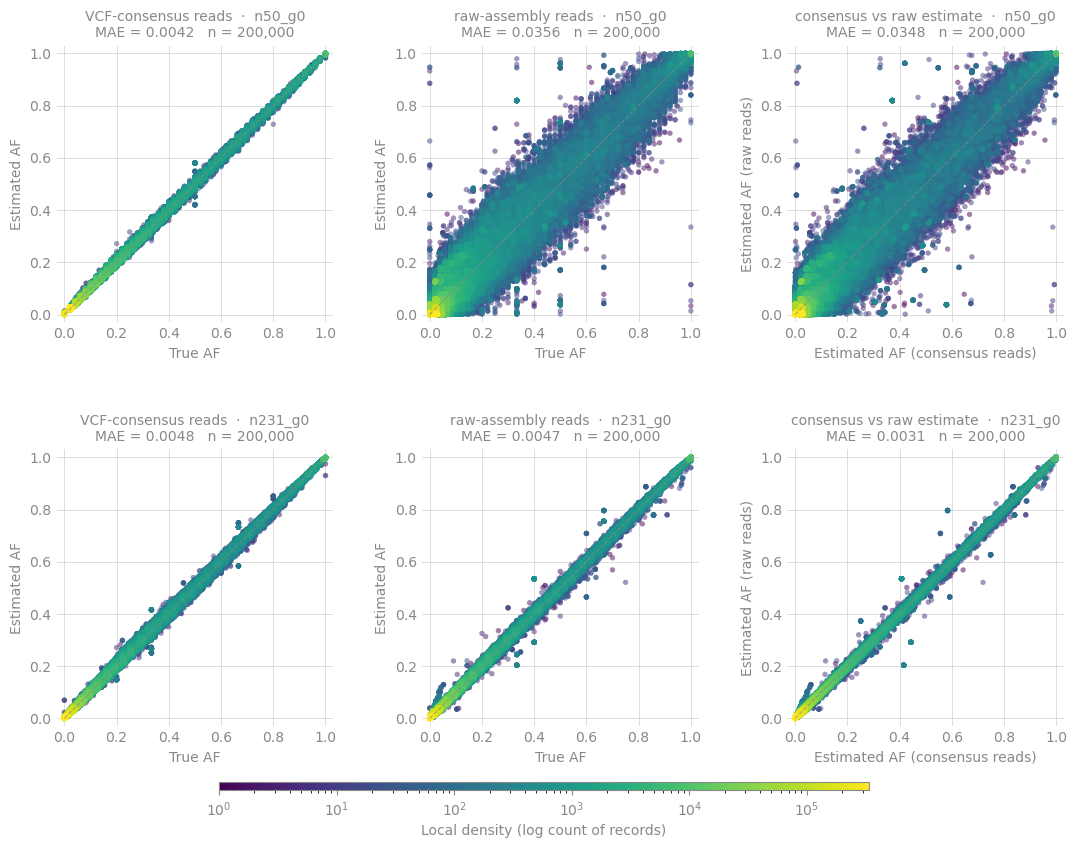

saved: plots/g0_raw_vs_consensus_validation.png

Consensus-vs-raw estimate agreement (the read substrate makes ~no difference):
  n50_g0    mean|Δ| = 0.03467   median|Δ| = 0.02176   max|Δ| = 0.9690   Pearson r = 0.96628
  n231_g0   mean|Δ| = 0.00309   median|Δ| = 0.00162   max|Δ| = 0.2123   Pearson r = 0.99944


In [2]:
# Validation scatters for the section above: true-vs-estimated AF for BOTH read
# substrates (VCF-consensus, raw-assembly), plus the consensus-est-vs-raw-est
# agreement panel (rightmost) that shows the two simulation routes estimate the
# same AF. `cactus_em global`, g0 regimes only. Reuses scatter_density_aesthetic /
# RESULTS / SIMS / REGIME_SIMDIR from the setup cell.
KEYS = ['chrom', 'pos', 'ref_len', 'alt_len']

def _load_est(path):
    return pd.read_csv(path, sep='\t')[KEYS + ['alt_freq']].drop_duplicates(KEYS)

g0_regimes = ['n50_g0', 'n231_g0']
val = {}
for reg in g0_regimes:
    truth = pd.read_csv(SIMS / REGIME_SIMDIR[reg] / 'recomb_truth.tsv.gz', sep='\t')
    truth = truth.dropna(subset=['truth_af']).drop_duplicates(KEYS)[KEYS + ['truth_af']]
    cons = _load_est(RESULTS / 'cactus_em_global'     / reg / f'p80_{reg}_cov10_s42.tsv').rename(columns={'alt_freq': 'est_cons'})
    raw  = _load_est(RESULTS / 'cactus_em_global_raw' / reg / f'p80_{reg}_cov10_s42.tsv').rename(columns={'alt_freq': 'est_raw'})
    val[reg] = truth.merge(cons, on=KEYS).merge(raw, on=KEYS)
    print(f'{reg}: joined {len(val[reg]):,} records')

fig, axes = plt.subplots(len(g0_regimes), 3, figsize=(13, 4.3 * len(g0_regimes)))
last_sm = None
for i, reg in enumerate(g0_regimes):
    m = val[reg]
    panels = [
        ('truth_af', 'est_cons', f'VCF-consensus reads  ·  {reg}', 'True AF', 'Estimated AF'),
        ('truth_af', 'est_raw',  f'raw-assembly reads  ·  {reg}',  'True AF', 'Estimated AF'),
        ('est_cons', 'est_raw',  f'consensus vs raw estimate  ·  {reg}', 'Estimated AF (consensus reads)', 'Estimated AF (raw reads)'),
    ]
    for j, (xc, yc, title, xl, yl) in enumerate(panels):
        ax = axes[i, j]
        sm = scatter_density_aesthetic(ax, m[xc].to_numpy(), m[yc].to_numpy(), title=title)
        if sm is not None:
            last_sm = sm
        ax.set_xlabel(xl); ax.set_ylabel(yl)

fig.subplots_adjust(bottom=0.11, top=0.92, hspace=0.38, wspace=0.32)
cbar_ax = fig.add_axes([0.25, 0.045, 0.50, 0.010])
if last_sm is not None:
    cb = fig.colorbar(last_sm, cax=cbar_ax, orientation='horizontal',
                      label='Local density (log count of records)')
    cb.outline.set_edgecolor(GREY)
    cb.ax.xaxis.set_tick_params(color=GREY, labelcolor=GREY)
    cb.ax.xaxis.label.set_color(GREY)

plt.savefig(PLOTS / 'g0_raw_vs_consensus_validation.png', dpi=130, bbox_inches='tight')
plt.show()
print('saved: plots/g0_raw_vs_consensus_validation.png')

# The "no variation" number: how far the two substrates' estimates differ from each other.
print('\nConsensus-vs-raw estimate agreement (the read substrate makes ~no difference):')
for reg in g0_regimes:
    m = val[reg]
    d = (m['est_raw'] - m['est_cons']).to_numpy()
    print(f'  {reg:8s}  mean|Δ| = {np.abs(d).mean():.5f}   median|Δ| = {np.median(np.abs(d)):.5f}   '
          f'max|Δ| = {np.abs(d).max():.4f}   Pearson r = {np.corrcoef(m.est_cons, m.est_raw)[0,1]:.5f}')


In [3]:
# Load cn_var meta -> canonical (chrom, pos, ref, alt) keys, 1:1 with row indices
meta = np.load(DATA / 'cn_var_p80.meta.npz', allow_pickle=True)
N = len(meta['pos'])
print(f'cn_var_p80: {N:,} records')
print(f'founders ({len(meta["founders"])}): {list(meta["founders"][:5])} ...')
print(f'chroms: {dict(zip(*np.unique(meta["chrom"], return_counts=True)))}')

# Build the canonical key DF (one row per cn_var record).
# Result/truth TSVs are row-aligned with cn_var.meta (verified by record count and first-3 spot check).
# Drop ref/alt object strings (they can be 100kb+ for SV alleles → memory blow-up
# when concat'd 4-8× across (method × regime × build) cells in long format).
key_df = pd.DataFrame({
    'chrom': meta['chrom'].astype(str),
    'pos':   meta['pos'].astype(np.int64),
    'ref_len': meta['ref_len'].astype(np.int32),
    'alt_len': meta['alt_len'].astype(np.int32),
})
key_df['var_class'] = np.where(
    (key_df['ref_len'] == 1) & (key_df['alt_len'] == 1), 'SNP',
    np.where(
        np.maximum(key_df['ref_len'], key_df['alt_len']) >= 50, 'SV',
        'indel'
    )
)
print('\nvariant class counts:')
print(key_df['var_class'].value_counts())


cn_var_p80: 2,048,842 records
founders (80): ['6911', '9910', '7143', '9879', '9506'] ...


chroms: {'Chr1': 2048842}



variant class counts:
var_class
SNP      1482759
indel     509923
SV         56160
Name: count, dtype: int64


## Per-record missingness — decide a filter threshold

Each cactus founder's GT at each record is either `0`, `1`, or `.` (missing — from the cactus pangenome's `CONFLICT` field when a sample's path through a snarl is ambiguous). The driver projects:

    est_AF[r] = (h @ cn_var[:, r]) / (h @ cn_var_called[:, r])

When `cn_var_called[:, r]` is sparse (few founders with non-`.` GT), the denominator is small → est_AF gets dominated by 1-2 founders' h-mass ratio → not a stable AF estimate.

This is a panel-level QC question: **at what missingness threshold do we drop a record?** Below: histogram + CDF + threshold table to inform a panel-wide filter we should also apply at production.


In [4]:
# Load called mask, compute per-record missingness fraction (0 = fully called, 1 = nothing called).
cn_called = sp.load_npz(DATA / 'cn_var_p80.cn_var_called.npz')
F = cn_called.shape[0]   # 80 founders
called_per_rec = np.asarray(cn_called.sum(axis=0)).ravel()
missing_frac = (F - called_per_rec) / F   # 0 = fully called, 1 = all missing
key_df['called_per_rec'] = called_per_rec.astype(np.int32)
key_df['missing_frac']   = missing_frac.astype(np.float32)

print(f'cn_var_called: {cn_called.shape}  nnz={cn_called.nnz:,}  density={cn_called.nnz/(F*N)*100:.2f}%')
print(f'mean missing_frac across records: {missing_frac.mean()*100:.2f}%')
print(f'median missing_frac:              {np.median(missing_frac)*100:.2f}%')

# Threshold table: how many records remain at each max-#missing cutoff?
print('\n=== Records retained by max #missing-founders threshold ===')
print(f'{"max_miss":>10s}  {"min_called":>12s}  {"n_kept":>12s}  {"frac_kept":>10s}')
for max_n_miss in [0, 1, 2, 4, 8, 16, 24, 32, 40, 60, 79]:
    min_called = F - max_n_miss
    n_kept = int(((F - called_per_rec) <= max_n_miss).sum())
    print(f'{max_n_miss:>10d}  >={min_called:>3d}/{F}     {n_kept:>12,}  {n_kept/N*100:>9.2f}%')


cn_var_called: (80, 2048842)  nnz=158,757,132  density=96.86%
mean missing_frac across records: 3.14%
median missing_frac:              0.00%

=== Records retained by max #missing-founders threshold ===
  max_miss    min_called        n_kept   frac_kept
         0  >= 80/80        1,755,600      85.69%
         1  >= 79/80        1,825,203      89.08%
         2  >= 78/80        1,851,460      90.37%
         4  >= 76/80        1,886,116      92.06%
         8  >= 72/80        1,919,687      93.70%
        16  >= 64/80        1,951,983      95.27%
        24  >= 56/80        1,972,911      96.29%
        32  >= 48/80        1,983,349      96.80%
        40  >= 40/80        1,996,295      97.44%
        60  >= 20/80        2,031,233      99.14%
        79  >=  1/80        2,048,842     100.00%


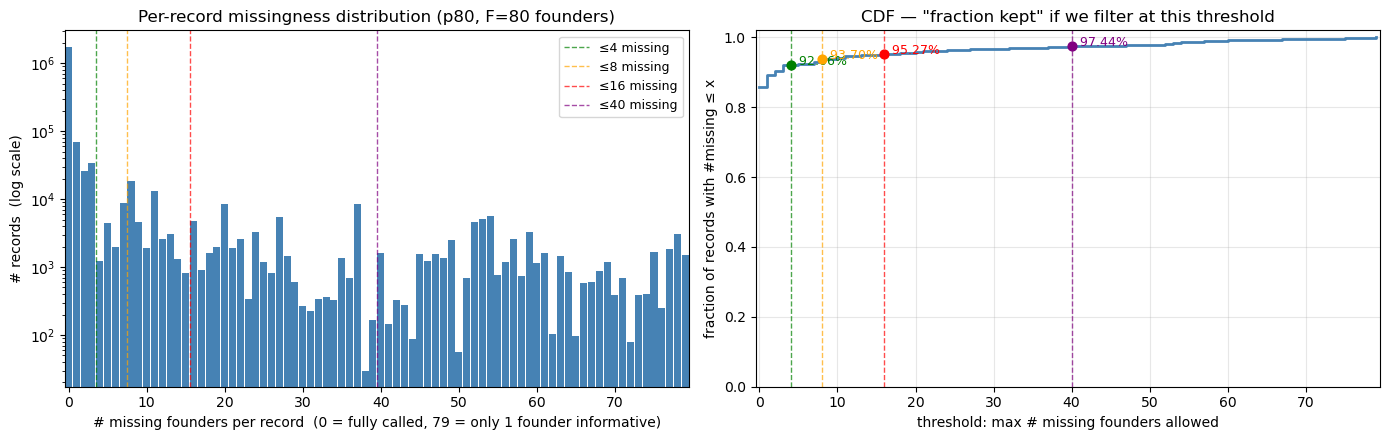

saved: missingness_diagnostic.png


In [5]:
# Histogram + CDF of missingness, indexed by INTEGER count of missing founders (0..79).
# x = number of missing founders out of F=80. 0 = fully called, 79 = only 1 founder informative.
n_missing = (F - called_per_rec).astype(int)   # integer count, 0..79

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# (1) Classical histogram — 1 bar per integer count.
ax = axes[0]
counts = np.bincount(n_missing, minlength=F)   # length F=80, index = # missing
ax.bar(np.arange(F), counts, width=0.9, color='steelblue', edgecolor='none')
ax.set_yscale('log')
ax.set_xlabel('# missing founders per record  (0 = fully called, 79 = only 1 founder informative)')
ax.set_ylabel('# records  (log scale)')
ax.set_title('Per-record missingness distribution (p80, F=80 founders)')
ax.set_xlim(-0.5, F - 0.5)
for thr_n, color in [(4, 'green'), (8, 'orange'), (16, 'red'), (40, 'purple')]:
    ax.axvline(thr_n - 0.5, color=color, ls='--', lw=1, alpha=0.7,
               label=f'≤{thr_n} missing')
ax.legend(fontsize=9, loc='upper right')

# (2) CDF — fraction of records with #missing <= x.
ax = axes[1]
cum_kept = np.cumsum(counts) / counts.sum()
ax.step(np.arange(F), cum_kept, where='post', color='steelblue', lw=2)
ax.set_xlabel('threshold: max # missing founders allowed')
ax.set_ylabel('fraction of records with #missing ≤ x')
ax.set_title('CDF — "fraction kept" if we filter at this threshold')
ax.set_xlim(-0.5, F - 0.5); ax.set_ylim(0, 1.02)
ax.grid(alpha=0.3)
for thr_n, color in [(4, 'green'), (8, 'orange'), (16, 'red'), (40, 'purple')]:
    f_kept = cum_kept[thr_n]
    ax.axvline(thr_n, color=color, ls='--', lw=1, alpha=0.7)
    ax.scatter([thr_n], [f_kept], color=color, s=40, zorder=5)
    ax.annotate(f'  {f_kept*100:.2f}%', xy=(thr_n, f_kept), color=color, fontsize=9)

plt.tight_layout()
plt.savefig(PLOTS / 'missingness_diagnostic.png', dpi=130, bbox_inches='tight')
plt.show()
print('saved: missingness_diagnostic.png')


In [6]:
# Load all 4 result TSVs + the per-regime truth TSV. Result rows are row-aligned with cn_var.meta.

def load_result(method, regime):
    """Returns (alt_freq, info_h, n_called, se) — new TSV schema (2026-05-21).
    Old TSVs without these columns will throw KeyError; rerun cactus_em."""
    tsv = RESULTS / f'cactus_em_{method}' / regime / f'p80_{regime}_cov10_s42.tsv'
    df = pd.read_csv(tsv, sep='\t')
    assert len(df) == N, f'{method}/{regime}: got {len(df)} rows, expected {N}'
    return (df['alt_freq'].to_numpy(),
            df['info'].to_numpy(),
            df['n_called'].to_numpy(),
            df['se'].to_numpy())

def load_truth(regime):
    """Returns (truth_af, truth_info, source_truth_af, source_info).
    Sim-dir name varies by regime (the dom500 skewed sim uses a different tag);
    REGIME_SIMDIR maps each regime to its actual sim subdirectory."""
    tsv_gz = SIMS / REGIME_SIMDIR[regime] / 'recomb_truth.tsv.gz'
    df = pd.read_csv(tsv_gz, sep='\t')
    assert len(df) == N, f'{regime} truth: got {len(df)} rows, expected {N}'
    src_af = df['source_truth_af'].to_numpy() if 'source_truth_af' in df.columns else None
    src_info = df['source_info'].to_numpy() if 'source_info' in df.columns else None
    return df['truth_af'].to_numpy(), df['info'].to_numpy(), src_af, src_info

# Build long-format DF: one row per (cell, record). Now includes per-record
# uncertainty (info_h = h-weighted, n_called = panel-side, se = Wald SE)
# from cactus_em output, plus the realized-pool truth + the infinite-pool
# source-population truth from the simulator.
rows = []
for regime in REGIMES:
    truth, truth_info, source_truth, source_info = load_truth(regime)
    for method in METHODS:
        est, info_h, n_called_est, se = load_result(method, regime)
        df = key_df.copy()
        df['truth'] = truth
        df['truth_info'] = truth_info
        df['source_truth'] = source_truth
        df['source_info'] = source_info
        df['est'] = est
        df['info_h'] = info_h
        df['n_called_est'] = n_called_est
        df['se'] = se
        df['regime'] = regime
        df['method'] = method
        rows.append(df)

big = pd.concat(rows, ignore_index=True)
print(f'long-format DF: {len(big):,} rows ({len(big)//N} cells × {N:,} records)')
print(big.head(3))


long-format DF: 24,586,104 rows (12 cells × 2,048,842 records)
  chrom  pos  ref_len  alt_len var_class  called_per_rec  missing_frac  \
0  Chr1    2        1     2161        SV              54         0.325   
1  Chr1    2        1     4527        SV              54         0.325   
2  Chr1    2        1     2334        SV              54         0.325   

      truth  truth_info  source_truth  source_info      est   info_h  \
0  0.018519       0.675      0.018519        0.675  0.01767  0.67511   
1  0.018519       0.675      0.018519        0.675  0.02029  0.67511   
2  0.018519       0.675      0.018519        0.675  0.02213  0.67511   

   n_called_est       se  regime  method  
0            54  0.01793  n80_g0  global  
1            54  0.01919  n80_g0  global  
2            54  0.02002  n80_g0  global  


In [7]:
# Per-(method, regime) summary. Drop records where truth and est are both 0 (uninformative
# for AF accuracy; bloats R² artificially). Keep records with truth>0 OR est>0.

def metrics(g):
    # Drop records with NaN truth (sim couldn't assign — info=0) or NaN est.
    valid = np.isfinite(g['truth']) & np.isfinite(g['est'])
    keep = valid & ((g['truth'] > 0) | (g['est'] > 0))
    g = g[keep]
    err = g['est'] - g['truth']
    mae = np.abs(err).mean()
    rmse = np.sqrt((err**2).mean())
    # R² (Pearson² as a sanity backup; lead with MAE)
    if g['truth'].std() > 0 and g['est'].std() > 0:
        r2 = float(np.corrcoef(g['truth'], g['est'])[0, 1]**2)
    else:
        r2 = float('nan')
    # OLS slope
    if g['truth'].var() > 0:
        slope = float(np.cov(g['truth'], g['est'])[0, 1] / g['truth'].var())
    else:
        slope = float('nan')
    outlier = (err.abs() > 0.10).mean()
    return pd.Series({
        'n_records': int(keep.sum()),
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'slope': slope,
        '|err|>0.10 frac': outlier,
    })

summary = (big.groupby(['method', 'regime'])
              .apply(metrics, include_groups=False)
              .reset_index())
print('\n=== Headline (vs realized-pool truth, no missingness filter) ===')
print(summary.to_string(index=False))



=== Headline (vs realized-pool truth, no missingness filter) ===
method        regime  n_records      MAE     RMSE       R2    slope  |err|>0.10 frac
global        n50_g0  2047837.0 0.004175 0.006613 0.998950 0.999814         0.000000
global        n50_g1  2045201.0 0.011511 0.019600 0.991215 0.992161         0.001386
global        n50_g3  2040234.0 0.026999 0.048776 0.948873 0.954070         0.070578
global n50_g3_dom500  2036004.0 0.046088 0.086926 0.857310 0.985678         0.169103
global        n80_g0  2048842.0 0.004523 0.007022 0.998801 0.999267         0.000000
global        n80_g1  2047212.0 0.010725 0.021906 0.988087 0.990186         0.001589
 star2        n50_g0  2047837.0 0.008043 0.013943 0.995294 0.995328         0.000847
 star2        n50_g1  2045201.0 0.011241 0.020354 0.990629 0.991869         0.002608
 star2        n50_g3  2040234.0 0.018321 0.033156 0.976440 0.972886         0.017711
 star2 n50_g3_dom500  2035929.0 0.044661 0.087328 0.861007 1.006616         0.157559

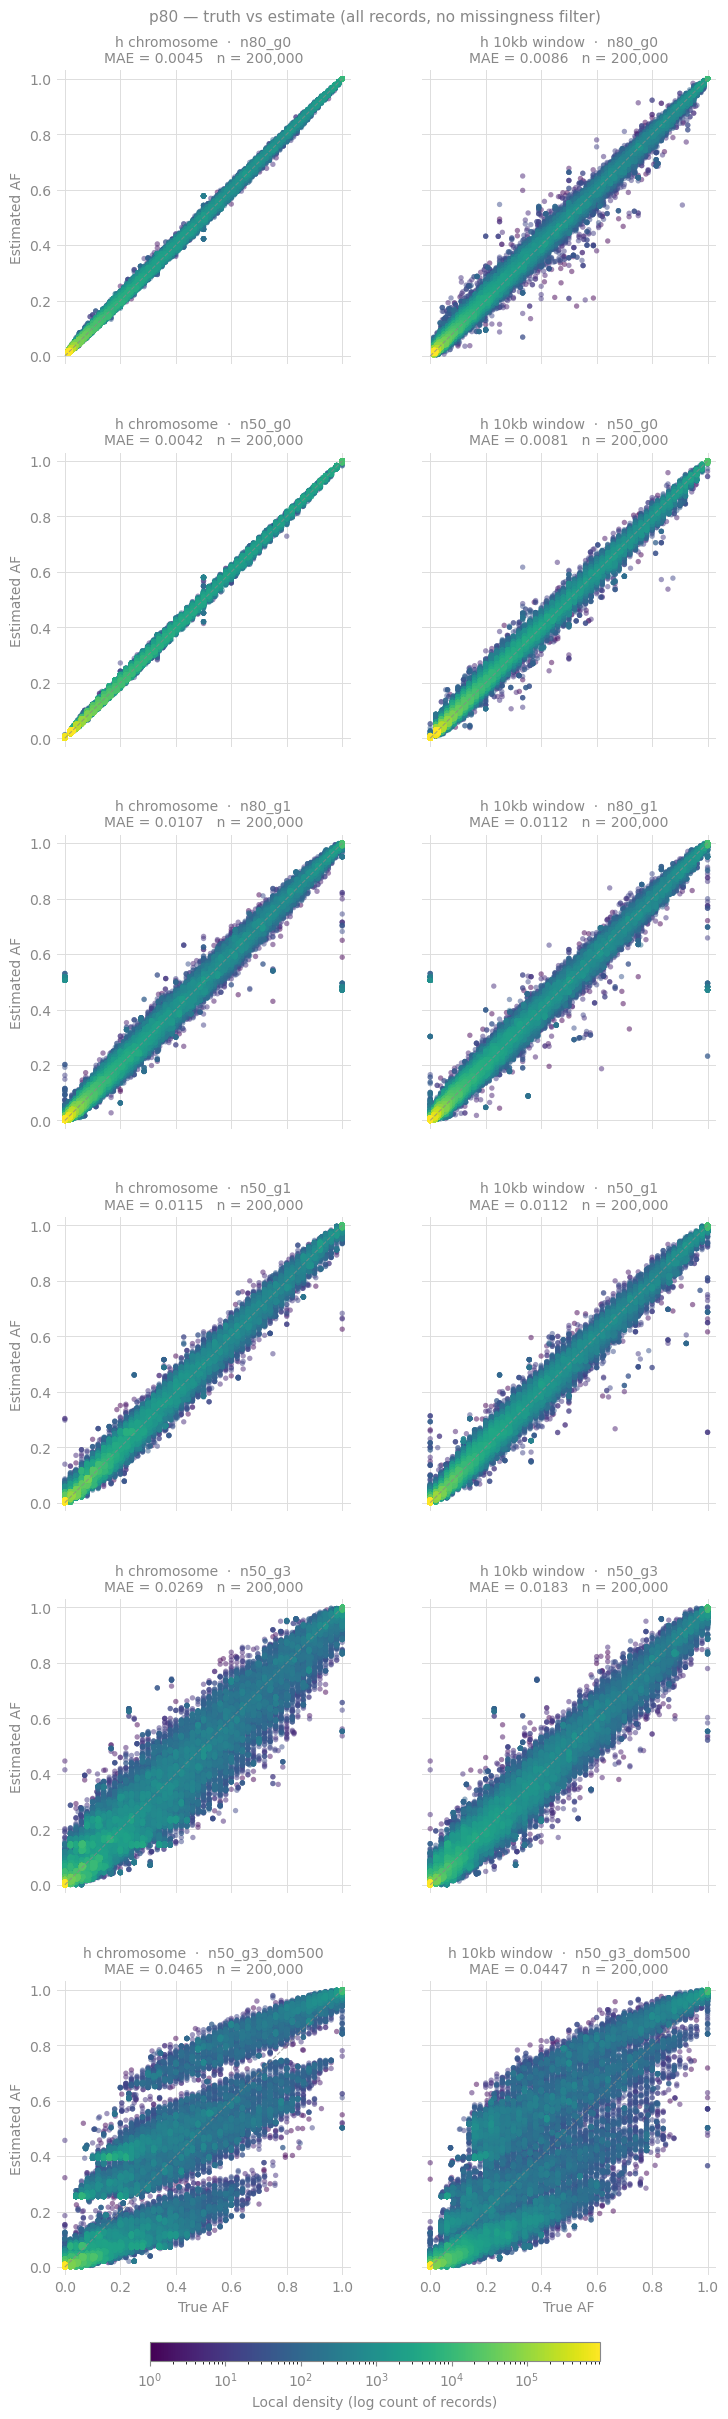

saved: plots/panel_truth_vs_est_no_filter.png


In [8]:
# Panel 1 of 2: NO missingness filter. All records. 6 regimes (easiest top)
# × 2 methods (h chromosome | h 10kb window). Square cells, shared density colorbar.
regime_method_panel(
    big, REGIMES, METHODS,
    suptitle='p80 — truth vs estimate (all records, no missingness filter)',
    filename='panel_truth_vs_est_no_filter.png',
)


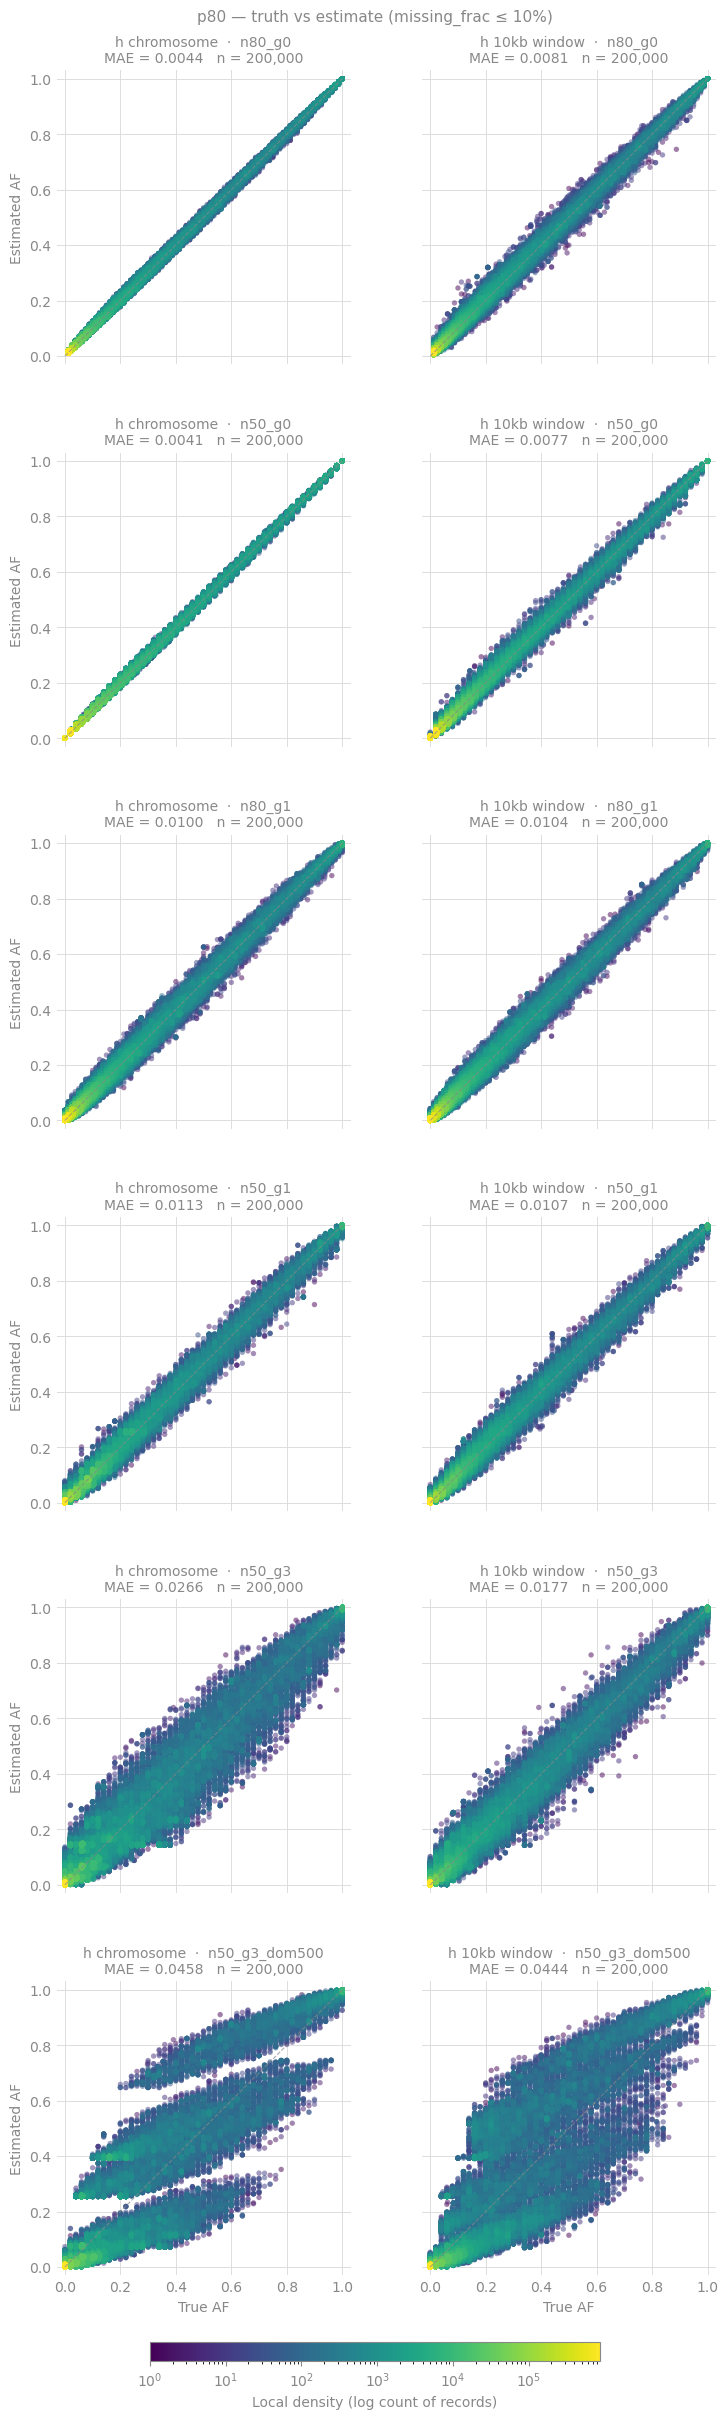

saved: plots/panel_truth_vs_est_miss10.png


In [9]:
# Panel 2 of 2: missingness filter (missing_frac <= 10%). Same layout.
# Drops ~3-4% of records (the high-missingness tail) — see histogram cell above.
regime_method_panel(
    big[big['missing_frac'] <= 0.10], REGIMES, METHODS,
    suptitle='p80 — truth vs estimate (missing_frac ≤ 10%)',
    filename='panel_truth_vs_est_miss10.png',
)


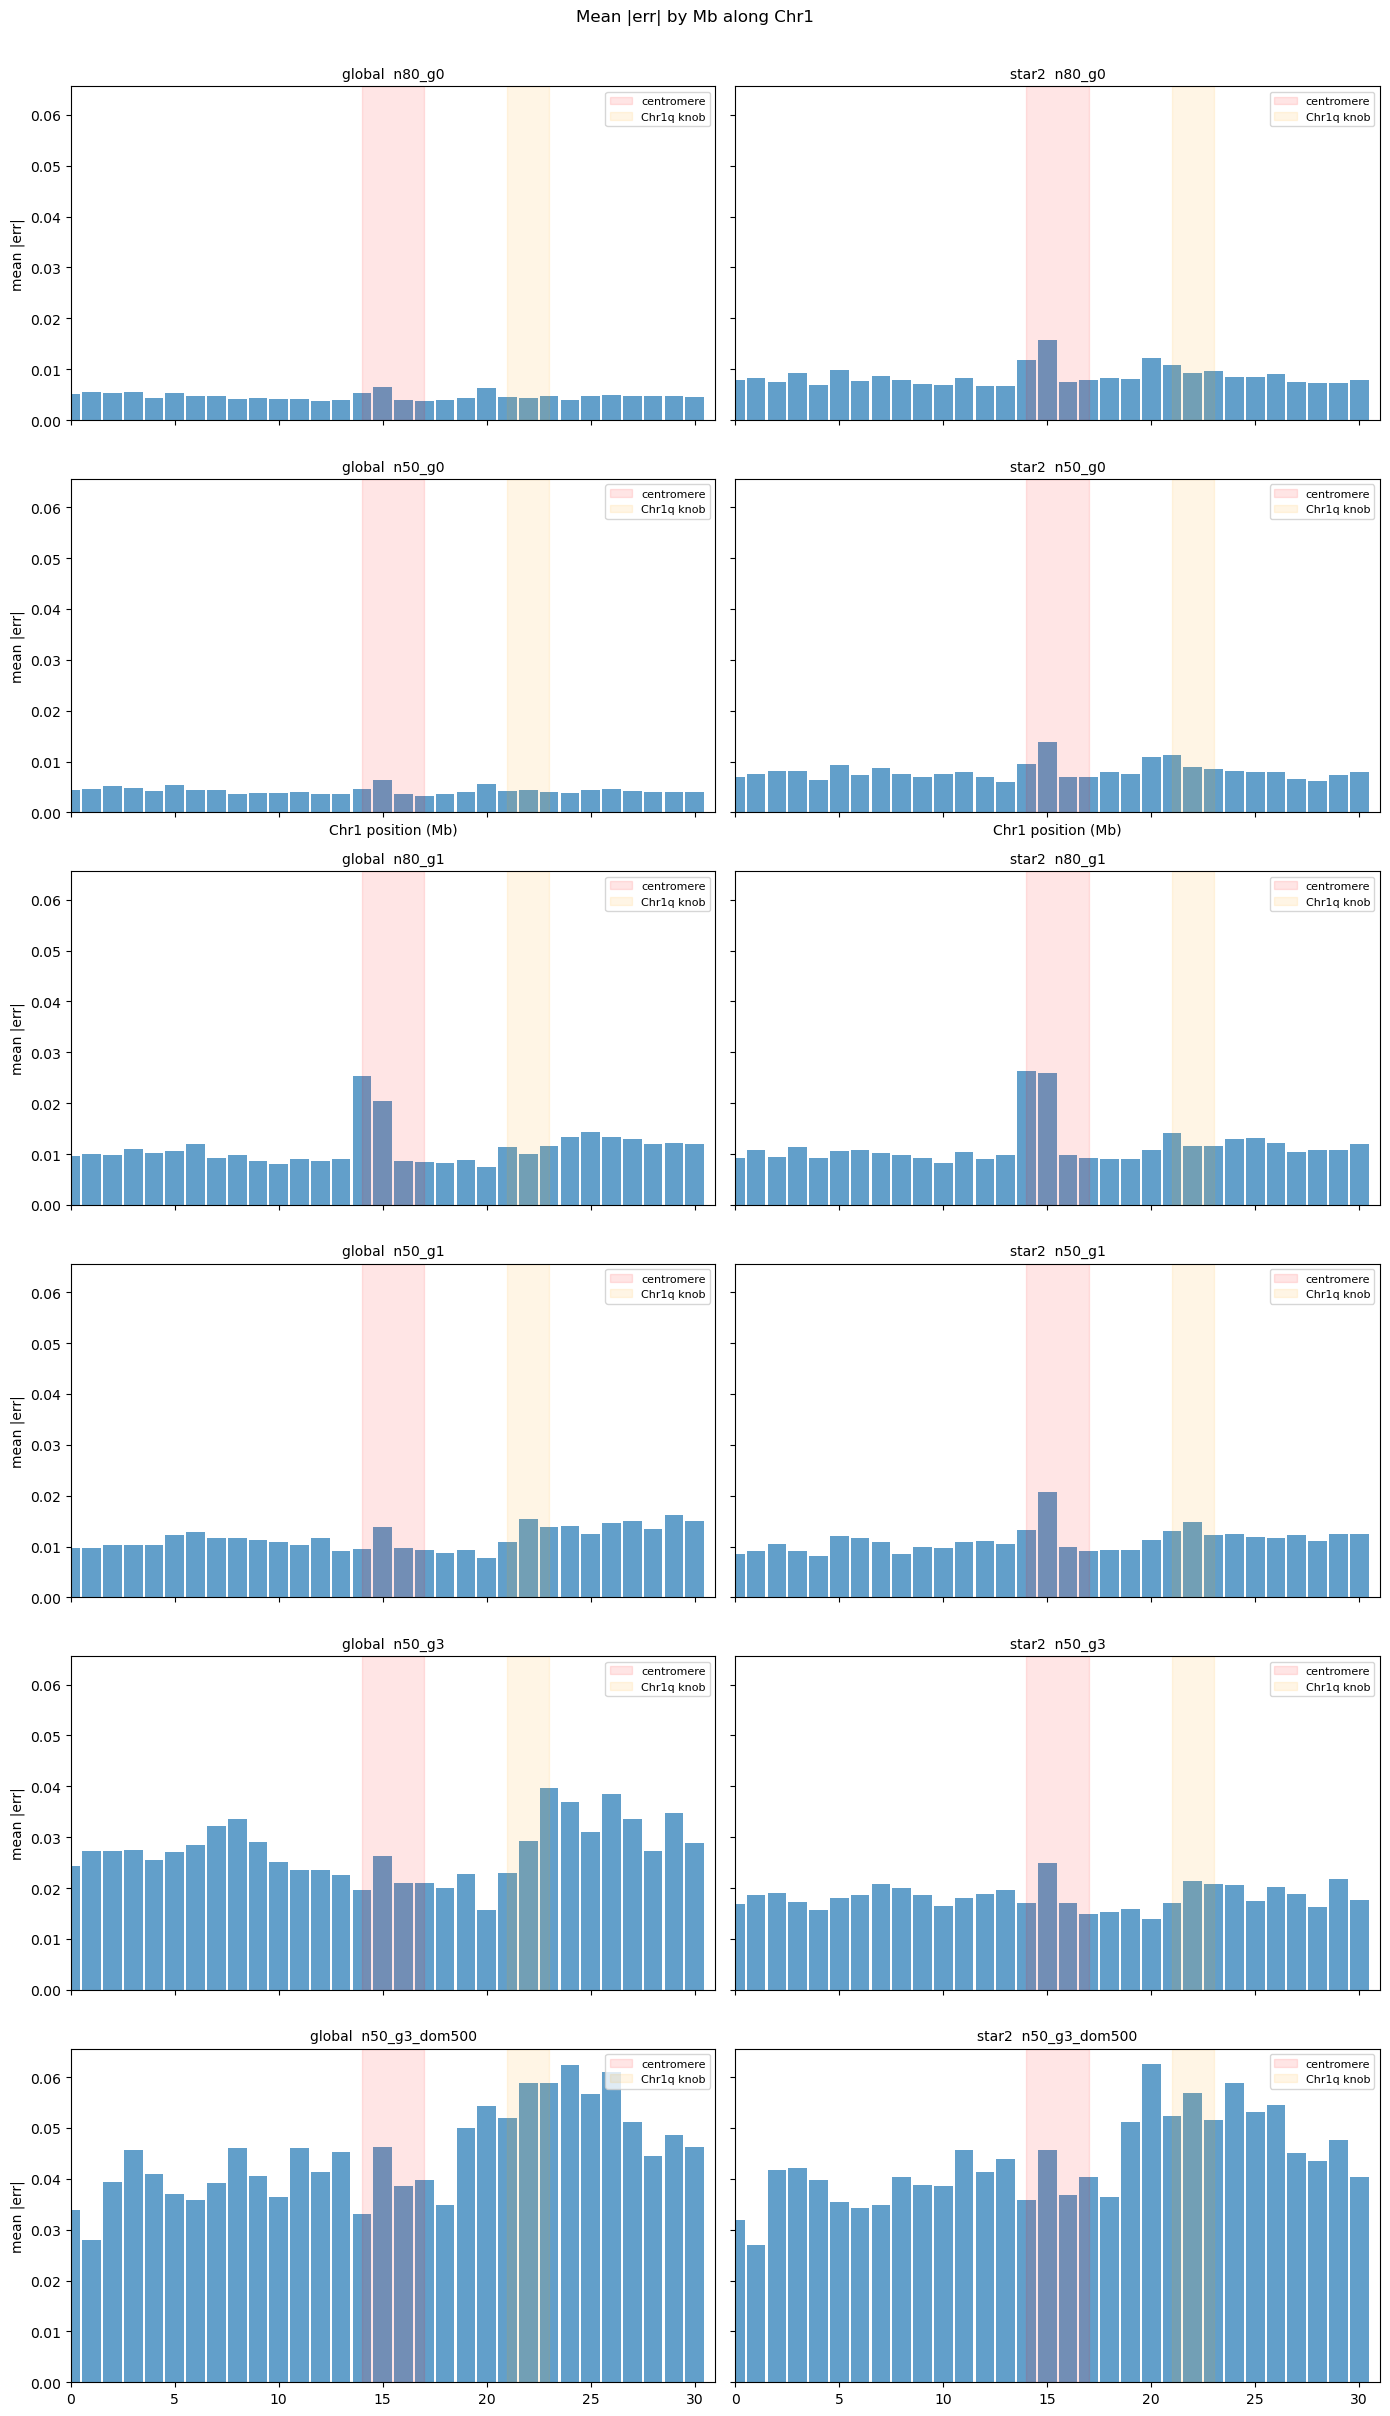

saved: err_by_mb.png


In [10]:
# Residual structure along Chr1 — Mb-binned mean |err| per cell. Identifies localized
# pathology (e.g. the centromere alignment dead zone, the Chr1q knob).
CHR1_LEN_MB = 31  # 30.4 Mb
fig, axes = plt.subplots(6, 2, figsize=(14, 24), sharex=True, sharey=True)
for i, regime in enumerate(REGIMES):
    for j, method in enumerate(METHODS):
        ax = axes[i, j]
        sub = big[(big['regime'] == regime) & (big['method'] == method)].copy()
        keep = (sub['truth'] > 0) | (sub['est'] > 0)
        sub = sub[keep]
        sub['mb'] = (sub['pos'] // 1_000_000).astype(int)
        agg = sub.groupby('mb').agg(
            mean_abs_err=('est', lambda x: np.abs(x - sub.loc[x.index, 'truth']).mean()),
            n=('est', 'size'),
            outlier_frac=('est', lambda x: (np.abs(x - sub.loc[x.index, 'truth']) > 0.1).mean()),
        ).reset_index()
        ax.bar(agg['mb'], agg['mean_abs_err'], width=0.9, alpha=0.7)
        # Mark centromere region (~Chr1 Mb 14-17)
        ax.axvspan(14, 17, color='red', alpha=0.10, label='centromere')
        ax.axvspan(21, 23, color='orange', alpha=0.10, label='Chr1q knob')
        ax.set_title(f'{method}  {regime}', fontsize=10)
        if i == 1: ax.set_xlabel('Chr1 position (Mb)')
        if j == 0: ax.set_ylabel('mean |err|')
        ax.legend(fontsize=8, loc='upper right')
        ax.set_xlim(0, CHR1_LEN_MB)
plt.suptitle('Mean |err| by Mb along Chr1', y=1.005, fontsize=12)
plt.tight_layout()
plt.savefig(PLOTS / 'err_by_mb.png', dpi=130, bbox_inches='tight')
plt.show()
print('saved: err_by_mb.png')


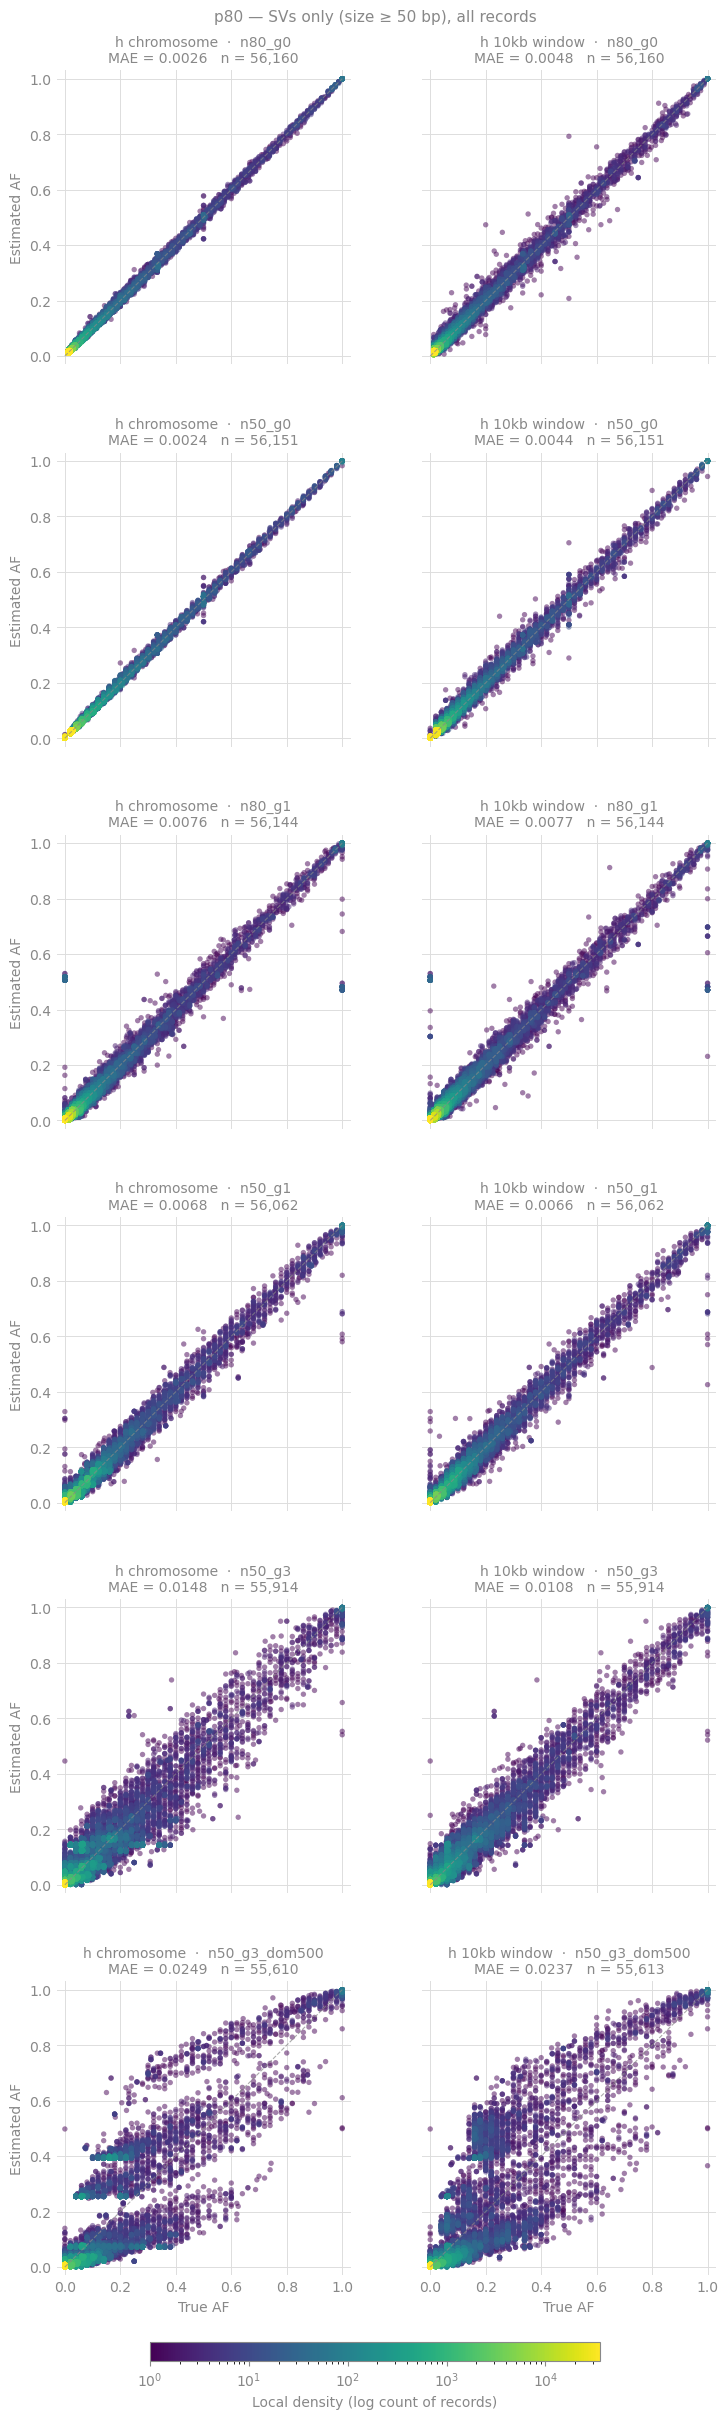

saved: plots/panel_truth_vs_est_SV_no_filter.png


In [11]:
# SV-only panel (size ≥ 50 bp). Same aesthetic as the main panel.
regime_method_panel(
    big[big['var_class'] == 'SV'], REGIMES, METHODS,
    suptitle='p80 — SVs only (size ≥ 50 bp), all records',
    filename='panel_truth_vs_est_SV_no_filter.png',
)


In [12]:
# MISSINGNESS FILTER. Decided from the diagnostic above.
# MAX_MISS = max acceptable per-record missingness fraction (0 = all founders called).
# Equivalent called-fraction threshold: called_per_rec >= (1-MAX_MISS) * 80.
MAX_MISS = 0.10   # change this and re-run downstream cells to A/B test thresholds

big_f = big[big['missing_frac'] <= MAX_MISS].copy()
n_kept = (key_df['missing_frac'] <= MAX_MISS).sum()
print(f'Filter: missing_frac <= {MAX_MISS*100:.1f}%  '
      f'(called >= {int(np.ceil((1-MAX_MISS)*80))}/80)')
print(f'Records kept: {n_kept:,} / {N:,}  ({n_kept/N*100:.2f}%)')
print(f'Records dropped: {N - n_kept:,}  ({(N-n_kept)/N*100:.2f}%)')

# Recompute headline summary on filtered set
summary_f = (big_f.groupby(['method', 'regime'])
                  .apply(metrics, include_groups=False)
                  .reset_index())
summary_f.insert(0, 'filter', f'miss<={MAX_MISS*100:.0f}%')

# Side-by-side comparison
compare = pd.concat([
    summary.assign(filter='all').loc[:, ['filter'] + list(summary.columns)],
    summary_f
], ignore_index=True).sort_values(['method', 'regime', 'filter']).reset_index(drop=True)
print('\n=== Headline: unfiltered vs missingness filter ===\n')
print(compare.to_string(index=False))


Filter: missing_frac <= 10.0%  (called >= 72/80)
Records kept: 1,919,687 / 2,048,842  (93.70%)
Records dropped: 129,155  (6.30%)



=== Headline: unfiltered vs missingness filter ===

   filter method        regime  n_records      MAE     RMSE       R2    slope  |err|>0.10 frac
      all global        n50_g0  2047837.0 0.004175 0.006613 0.998950 0.999814         0.000000
miss<=10% global        n50_g0  1919687.0 0.004077 0.006339 0.998974 1.000362         0.000000
      all global        n50_g1  2045201.0 0.011511 0.019600 0.991215 0.992161         0.001386
miss<=10% global        n50_g1  1919687.0 0.011258 0.018864 0.991268 0.993898         0.000685
      all global        n50_g3  2040234.0 0.026999 0.048776 0.948873 0.954070         0.070578
miss<=10% global        n50_g3  1919687.0 0.026687 0.047790 0.948517 0.953428         0.069156
      all global n50_g3_dom500  2036004.0 0.046088 0.086926 0.857310 0.985678         0.169103
miss<=10% global n50_g3_dom500  1915609.0 0.045855 0.086166 0.853939 0.987206         0.169101
      all global        n80_g0  2048842.0 0.004523 0.007022 0.998801 0.999267         0.0000

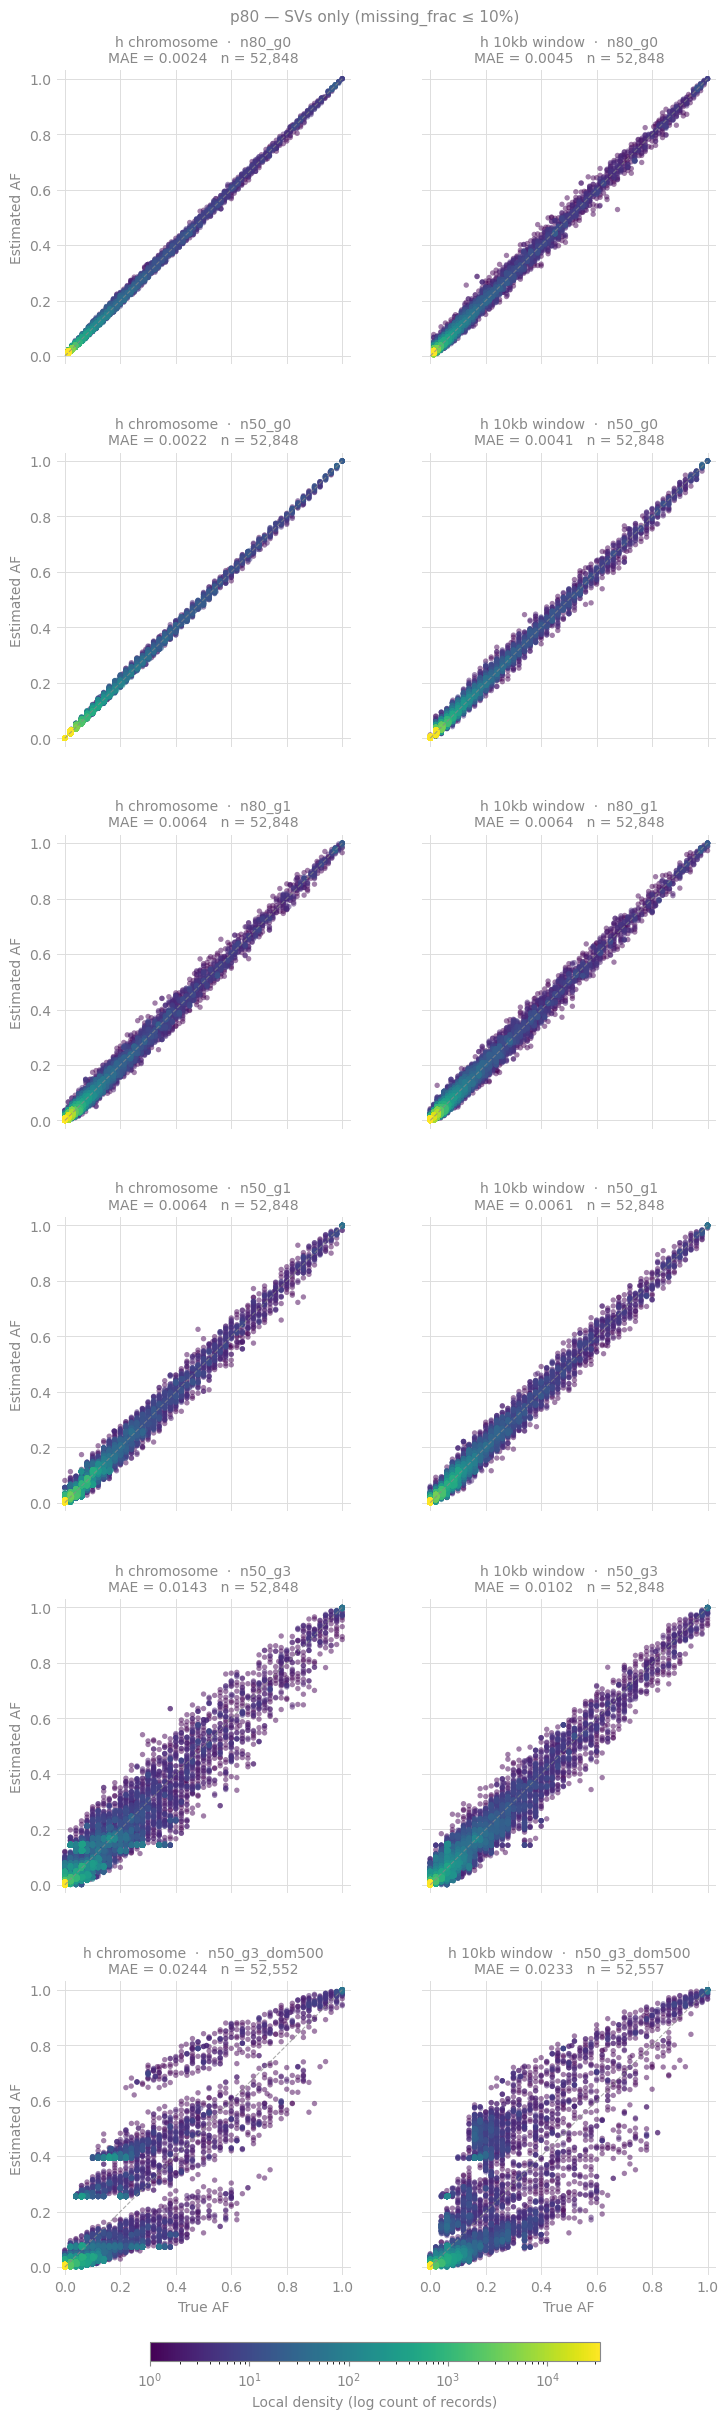

saved: plots/panel_truth_vs_est_SV_miss10.png


In [13]:
# SV-only panel with missingness filter (missing_frac <= MAX_MISS).
regime_method_panel(
    big_f[big_f['var_class'] == 'SV'], REGIMES, METHODS,
    suptitle=f'p80 — SVs only (missing_frac ≤ {MAX_MISS*100:.0f}%)',
    filename='panel_truth_vs_est_SV_miss10.png',
)


In [14]:
# Per-variant-class breakdown WITH and WITHOUT the called filter.
def by_class(g):
    out = []
    for cls in ['SNP', 'indel', 'SV']:
        sub = g[g['var_class'] == cls]
        if len(sub) == 0:
            continue
        r = metrics(sub)
        r['var_class'] = cls
        out.append(r)
    return pd.DataFrame(out)

sc_all = (big.groupby(['method', 'regime']).apply(by_class, include_groups=False)
              .reset_index().drop(columns='level_2').assign(filter='all'))
sc_f = (big_f.groupby(['method', 'regime']).apply(by_class, include_groups=False)
              .reset_index().drop(columns='level_2').assign(filter=f'miss<={MAX_MISS*100:.0f}%'))
summary_class = pd.concat([sc_all, sc_f], ignore_index=True)
summary_class = summary_class[['filter','method','regime','var_class','n_records','MAE','RMSE','R2','slope','|err|>0.10 frac']]
print('=== Per-variant-class: unfiltered vs missingness filter ===')
print(summary_class.sort_values(['method','regime','var_class','filter']).to_string(index=False))
summary_class.to_csv(RESULTS / 'summary_by_var_class.csv', index=False)


=== Per-variant-class: unfiltered vs missingness filter ===
   filter method        regime var_class  n_records      MAE     RMSE       R2    slope  |err|>0.10 frac
      all global        n50_g0       SNP  1481950.0 0.004250 0.006701 0.998991 0.999907         0.000000
miss<=10% global        n50_g0       SNP  1381350.0 0.004147 0.006420 0.999011 1.000517         0.000000
      all global        n50_g0        SV    56151.0 0.002374 0.004154 0.998527 0.998736         0.000000
miss<=10% global        n50_g0        SV    52848.0 0.002235 0.003725 0.998605 0.999758         0.000000
      all global        n50_g0     indel   509736.0 0.004156 0.006576 0.998797 0.999296         0.000000
miss<=10% global        n50_g0     indel   485489.0 0.004077 0.006330 0.998846 0.999627         0.000000
      all global        n50_g1       SNP  1479935.0 0.011626 0.019705 0.991658 0.992630         0.001399
miss<=10% global        n50_g1       SNP  1381350.0 0.011356 0.018930 0.991691 0.994440         0.00

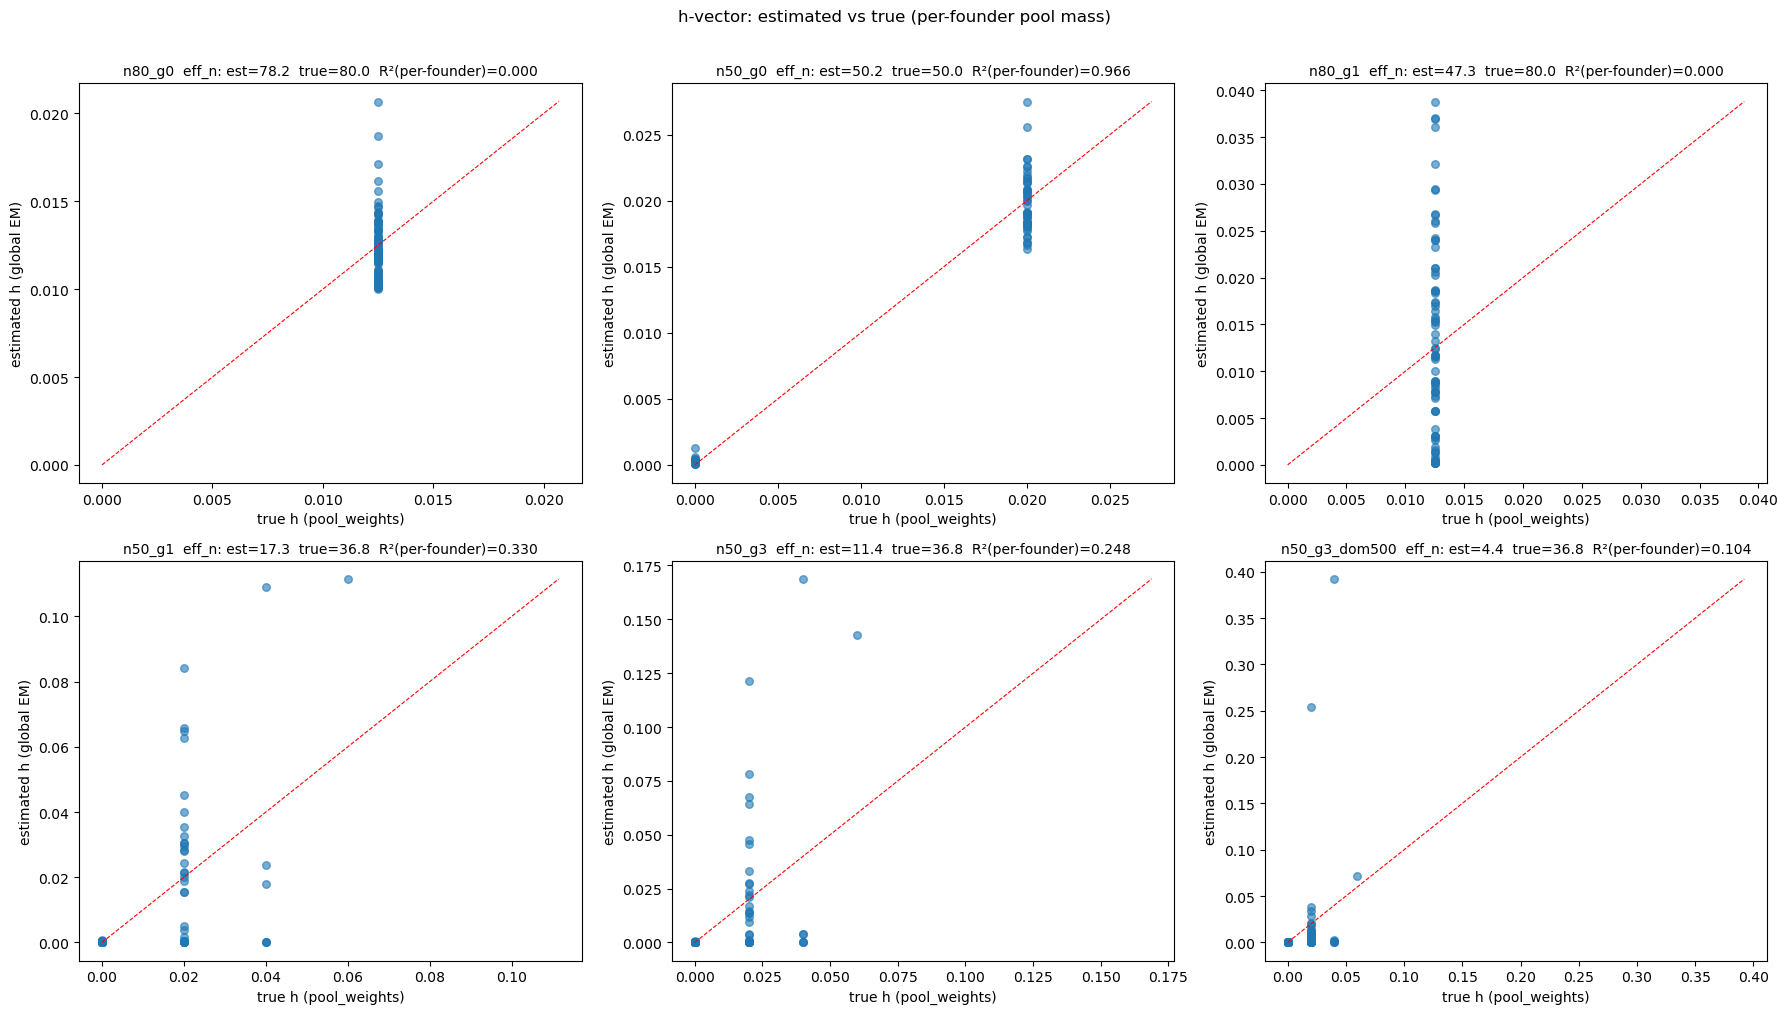

saved: h_vector_global.png


In [15]:
# h-vector comparison: estimated h (from global mode) vs the true pool weights.
# global mode writes h_per_chrom.npz; star2 writes h_blocks_per_chrom.npz (per-window) — skip per-window here.

def load_h(method, regime):
    if method == 'global':
        f = RESULTS / f'cactus_em_global/{regime}/p80_{regime}_cov10_s42.h_per_chrom.npz'
    else:
        return None  # star2 is per-window; do separately
    d = np.load(f, allow_pickle=True)
    return d['founders'], d['Chr1']

def load_truth_h(regime):
    f = SIMS / REGIME_SIMDIR[regime] / 'pool_weights.tsv'
    df = pd.read_csv(f, sep='\t')
    return df

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for j, regime in enumerate(REGIMES):
    founders, h_est = load_h('global', regime)
    truth = load_truth_h(regime)
    # Align by founder name
    truth_d = dict(zip(truth['founder'].astype(str), truth['weight']))
    h_true = np.array([truth_d.get(str(f), 0) for f in founders])
    ax = axes.ravel()[j]
    ax.scatter(h_true, h_est, alpha=0.6, s=30)
    ax.plot([0, max(h_true.max(), h_est.max())], [0, max(h_true.max(), h_est.max())],
            'r--', lw=0.8)
    ax.set_xlabel('true h (pool_weights)')
    ax.set_ylabel('estimated h (global EM)')
    # Effective number of founders: 1 / sum(h^2)
    eff_n_est = 1.0 / (h_est ** 2).sum() if (h_est**2).sum() > 0 else 0
    eff_n_true = 1.0 / (h_true ** 2).sum() if (h_true**2).sum() > 0 else 0
    r2_h = float(np.corrcoef(h_true, h_est)[0, 1]**2) if h_true.std() > 0 else float('nan')
    ax.set_title(f'{regime}  '
                 f'eff_n: est={eff_n_est:.1f}  true={eff_n_true:.1f}  '
                 f'R²(per-founder)={r2_h:.3f}', fontsize=10)
plt.suptitle('h-vector: estimated vs true (per-founder pool mass)', y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig(PLOTS / 'h_vector_global.png', dpi=130, bbox_inches='tight')
plt.show()
print('saved: h_vector_global.png')


In [16]:
# Headline summary as a clean Markdown-ready table.
print('=== Headline metrics (all variants where truth>0 or est>0) ===\n')
hl = summary[['method', 'regime', 'n_records', 'MAE', 'RMSE', 'R2', 'slope', '|err|>0.10 frac']].copy()
hl['MAE'] = hl['MAE'].apply(lambda x: f'{x:.4f}')
hl['RMSE'] = hl['RMSE'].apply(lambda x: f'{x:.4f}')
hl['R2'] = hl['R2'].apply(lambda x: f'{x:.4f}')
hl['slope'] = hl['slope'].apply(lambda x: f'{x:+.3f}')
hl['|err|>0.10 frac'] = hl['|err|>0.10 frac'].apply(lambda x: f'{x*100:.2f}%')
print(hl.to_string(index=False))

print('\n=== Per-variant-class ===\n')
sc = summary_class.copy()
sc['MAE'] = sc['MAE'].apply(lambda x: f'{x:.4f}')
sc['RMSE'] = sc['RMSE'].apply(lambda x: f'{x:.4f}')
sc['R2'] = sc['R2'].apply(lambda x: f'{x:.4f}')
sc['slope'] = sc['slope'].apply(lambda x: f'{x:+.3f}')
sc['|err|>0.10 frac'] = sc['|err|>0.10 frac'].apply(lambda x: f'{x*100:.2f}%')
print(sc[['method', 'regime', 'var_class', 'n_records', 'MAE', 'RMSE', 'R2', 'slope', '|err|>0.10 frac']].to_string(index=False))

# Save summary CSVs alongside the notebook
summary.to_csv(RESULTS / 'summary_headline.csv', index=False)
summary_class.to_csv(RESULTS / 'summary_by_var_class.csv', index=False)
print('\nsaved: summary_headline.csv, summary_by_var_class.csv')


=== Headline metrics (all variants where truth>0 or est>0) ===

method        regime  n_records    MAE   RMSE     R2  slope |err|>0.10 frac
global        n50_g0  2047837.0 0.0042 0.0066 0.9989 +1.000           0.00%
global        n50_g1  2045201.0 0.0115 0.0196 0.9912 +0.992           0.14%
global        n50_g3  2040234.0 0.0270 0.0488 0.9489 +0.954           7.06%
global n50_g3_dom500  2036004.0 0.0461 0.0869 0.8573 +0.986          16.91%
global        n80_g0  2048842.0 0.0045 0.0070 0.9988 +0.999           0.00%
global        n80_g1  2047212.0 0.0107 0.0219 0.9881 +0.990           0.16%
 star2        n50_g0  2047837.0 0.0080 0.0139 0.9953 +0.995           0.08%
 star2        n50_g1  2045201.0 0.0112 0.0204 0.9906 +0.992           0.26%
 star2        n50_g3  2040234.0 0.0183 0.0332 0.9764 +0.973           1.77%
 star2 n50_g3_dom500  2035929.0 0.0447 0.0873 0.8610 +1.007          15.76%
 star2        n80_g0  2048842.0 0.0085 0.0147 0.9947 +0.994           0.16%
 star2        n80_g1  20

## SE calibration — are the per-record SEs honest?

Each method now reports per-record `alt_freq`, `info` (h-weighted observed mass) and `se` (Wald SE using `n_called`). If the SE is well-calibrated, standardized residuals `(est - truth) / se` should look like N(0, 1). Deviations indicate either bias (mean ≠ 0) or mis-scaled uncertainty (std ≠ 1).


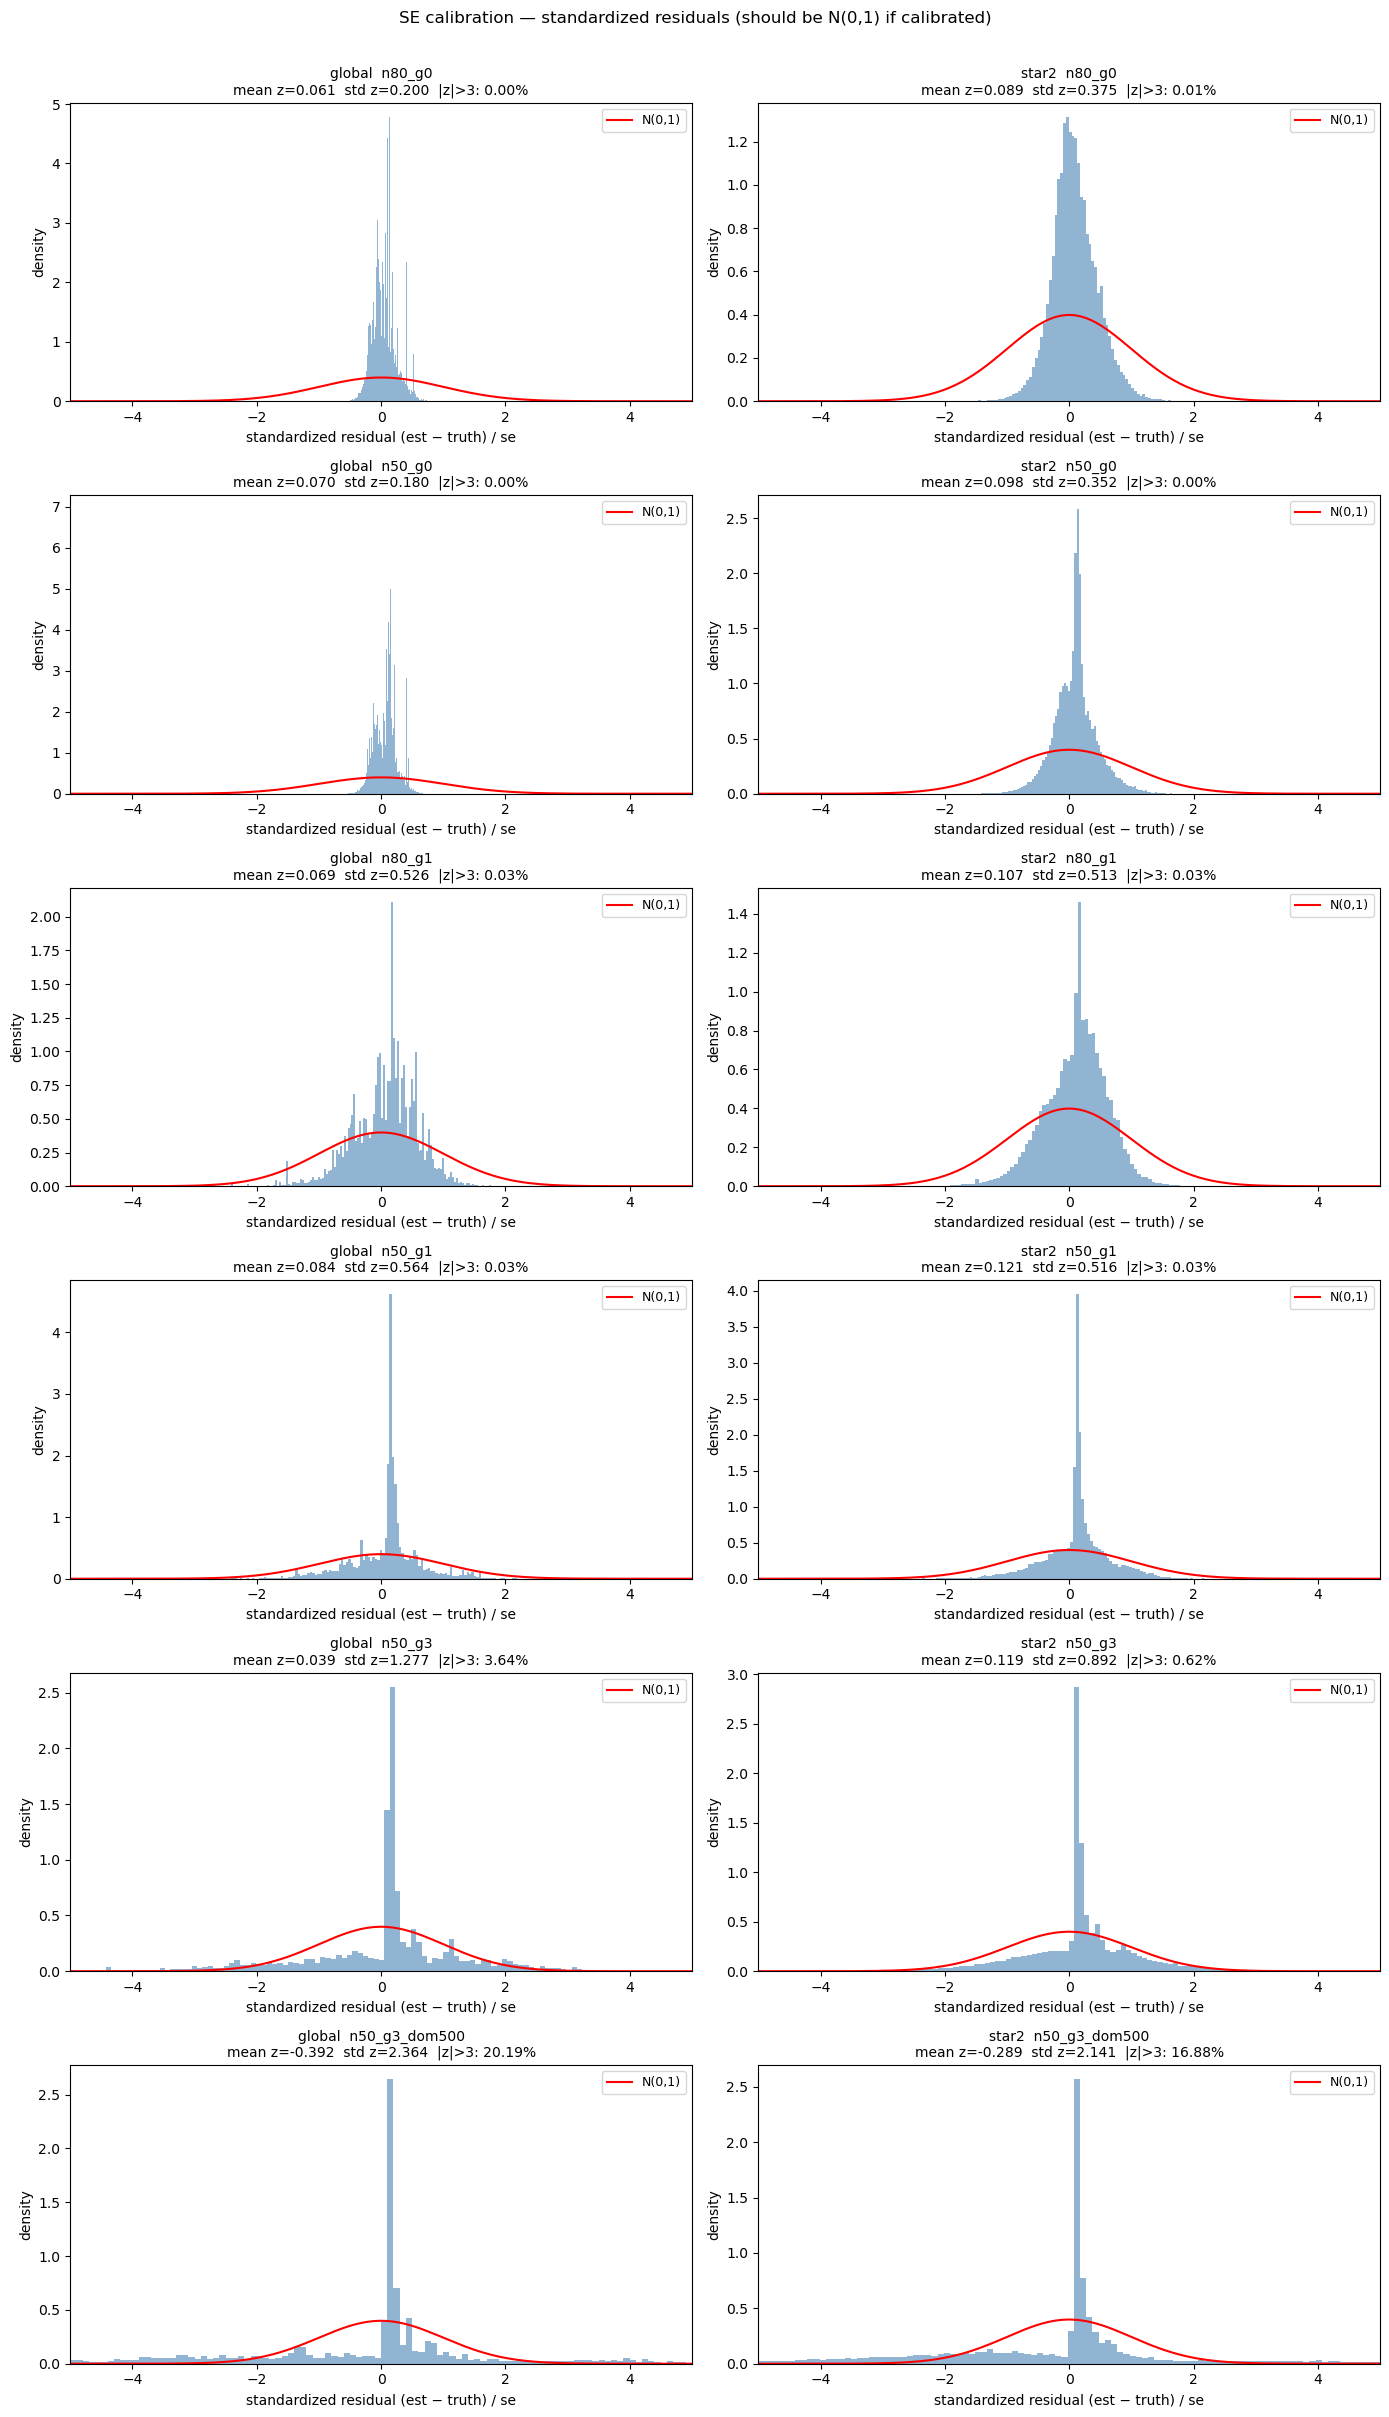

saved: se_calibration.png


In [17]:
fig, axes = plt.subplots(6, 2, figsize=(14, 24))
for i, regime in enumerate(REGIMES):
    for j, method in enumerate(METHODS):
        ax = axes[i, j]
        sub = big[(big['regime']==regime) & (big['method']==method)].copy()
        finite = np.isfinite(sub['truth']) & np.isfinite(sub['est']) & (sub['se'] > 0)
        sub = sub[finite]
        if len(sub) == 0:
            continue
        z = ((sub['est'] - sub['truth']) / sub['se']).to_numpy()
        # Trim to a reasonable display range
        z_trim = z[np.abs(z) < 10]
        ax.hist(z_trim, bins=200, density=True, alpha=0.6, color='steelblue', edgecolor='none')
        # Overlay N(0,1)
        xx = np.linspace(-5, 5, 200)
        ax.plot(xx, np.exp(-xx**2/2)/np.sqrt(2*np.pi), 'r-', lw=1.5, label='N(0,1)')
        ax.set_xlabel('standardized residual (est − truth) / se')
        ax.set_ylabel('density')
        ax.set_title(f'{method}  {regime}\n'
                     f'mean z={z.mean():.3f}  std z={z.std():.3f}  '
                     f'|z|>3: {(np.abs(z)>3).mean()*100:.2f}%',
                     fontsize=10)
        ax.set_xlim(-5, 5)
        ax.legend(fontsize=9)
plt.suptitle('SE calibration — standardized residuals (should be N(0,1) if calibrated)',
             y=1.005, fontsize=12)
plt.tight_layout()
plt.savefig(PLOTS / 'se_calibration.png', dpi=130, bbox_inches='tight')
plt.show()
print('saved: se_calibration.png')


## A/B test: filt2 vs no-filt2

`filt2` = pre-filter cn_full to drop k-mers with carrier-count < 2 (kill singleton k-mers). Hypothesis: with 80 cactus founders and no PG, singleton k-mers can still over-pin specific founders → filt2 should tighten h and reduce MAE. Same EM driver, same cn_var/cn_var_called/truth — only the k-mer dictionary fed to EM differs.


In [18]:
# Load filt2 results (new schema: alt_freq, info, n_called, se columns).
def load_result_filt2(method, regime):
    tsv = RESULTS / f'cactus_em_{method}_filt2' / regime / f'p80_filt2_{regime}_cov10_s42.tsv'
    if not tsv.exists():
        return None
    df = pd.read_csv(tsv, sep='\t')
    return (df['alt_freq'].to_numpy(),
            df['info'].to_numpy(),
            df['n_called'].to_numpy(),
            df['se'].to_numpy())

rows_f2 = []
for regime in REGIMES:
    truth, truth_info, _source_truth, _source_info = load_truth(regime)
    for method in METHODS:
        loaded = load_result_filt2(method, regime)
        if loaded is None:
            print(f'SKIP filt2 {method}/{regime}: not present yet')
            continue
        est, info_h, n_called_est, se = loaded
        df = key_df.copy()
        df['truth'] = truth
        df['truth_info'] = truth_info
        df['est'] = est
        df['info_h'] = info_h
        df['n_called_est'] = n_called_est
        df['se'] = se
        df['regime'] = regime
        df['method'] = method
        df['build'] = 'filt2'
        rows_f2.append(df)

if rows_f2:
    big_filt2 = pd.concat(rows_f2, ignore_index=True)
    big_with_build = pd.concat([big.assign(build='no_filt2'), big_filt2], ignore_index=True)
    # apply same missingness filter for an apples-to-apples comparison
    big_with_build_f = big_with_build[big_with_build['missing_frac'] <= MAX_MISS]

    summary_ab = (big_with_build_f.groupby(['build','method','regime'])
                                 .apply(metrics, include_groups=False)
                                 .reset_index())
    print(f'=== filt2 vs no_filt2 (post missingness filter: miss<={MAX_MISS*100:.0f}%) ===\n')
    print(summary_ab.to_string(index=False))

    # Per-variant-class for the filt2 vs no_filt2 contrast
    def by_class_filt2(g):
        out = []
        for cls in ['SNP', 'indel', 'SV']:
            sub = g[g['var_class'] == cls]
            if len(sub) == 0: continue
            r = metrics(sub); r['var_class'] = cls
            out.append(r)
        return pd.DataFrame(out)

    sc_ab = (big_with_build_f.groupby(['build','method','regime'])
                            .apply(by_class_filt2, include_groups=False)
                            .reset_index().drop(columns='level_3'))
    print(f'\n=== filt2 vs no_filt2 by variant class (post missingness filter) ===\n')
    print(sc_ab.sort_values(['method','regime','var_class','build']).to_string(index=False))


SKIP filt2 global/n80_g0: not present yet
SKIP filt2 star2/n80_g0: not present yet


SKIP filt2 global/n50_g0: not present yet
SKIP filt2 star2/n50_g0: not present yet


SKIP filt2 global/n80_g1: not present yet
SKIP filt2 star2/n80_g1: not present yet


SKIP filt2 global/n50_g3_dom500: not present yet
SKIP filt2 star2/n50_g3_dom500: not present yet


=== filt2 vs no_filt2 (post missingness filter: miss<=10%) ===

   build method        regime  n_records      MAE     RMSE       R2    slope  |err|>0.10 frac
   filt2 global        n50_g1  1872339.0 0.012747 0.021031 0.989315 0.986634         0.001638
   filt2 global        n50_g3  1869005.0 0.027618 0.050368 0.943930 0.948766         0.060547
   filt2  star2        n50_g1  1846266.0 0.012973 0.021472 0.988920 0.987961         0.002157
   filt2  star2        n50_g3  1868138.0 0.021330 0.038417 0.967342 0.964157         0.033784
no_filt2 global        n50_g0  1919687.0 0.004077 0.006339 0.998974 1.000362         0.000000
no_filt2 global        n50_g1  1919687.0 0.011258 0.018864 0.991268 0.993898         0.000685
no_filt2 global        n50_g3  1919687.0 0.026687 0.047790 0.948517 0.953428         0.069156
no_filt2 global n50_g3_dom500  1915609.0 0.045855 0.086166 0.853939 0.987206         0.169101
no_filt2 global        n80_g0  1919687.0 0.004406 0.006699 0.998830 0.999804         0.000


=== filt2 vs no_filt2 by variant class (post missingness filter) ===

   build method        regime  n_records      MAE     RMSE       R2    slope  |err|>0.10 frac var_class
no_filt2 global        n50_g0  1381350.0 0.004147 0.006420 0.999011 1.000517         0.000000       SNP
no_filt2 global        n50_g0    52848.0 0.002235 0.003725 0.998605 0.999758         0.000000        SV
no_filt2 global        n50_g0   485489.0 0.004077 0.006330 0.998846 0.999627         0.000000     indel
   filt2 global        n50_g1  1346190.0 0.012849 0.021083 0.989858 0.987194         0.001625       SNP
no_filt2 global        n50_g1  1381350.0 0.011356 0.018930 0.991691 0.994440         0.000667       SNP
   filt2 global        n50_g1    51098.0 0.007547 0.014299 0.982358 0.979768         0.000294        SV
no_filt2 global        n50_g1    52848.0 0.006445 0.012601 0.985912 0.988481         0.000170        SV
   filt2 global        n50_g1   475051.0 0.013016 0.021488 0.987524 0.984925         0.001819    

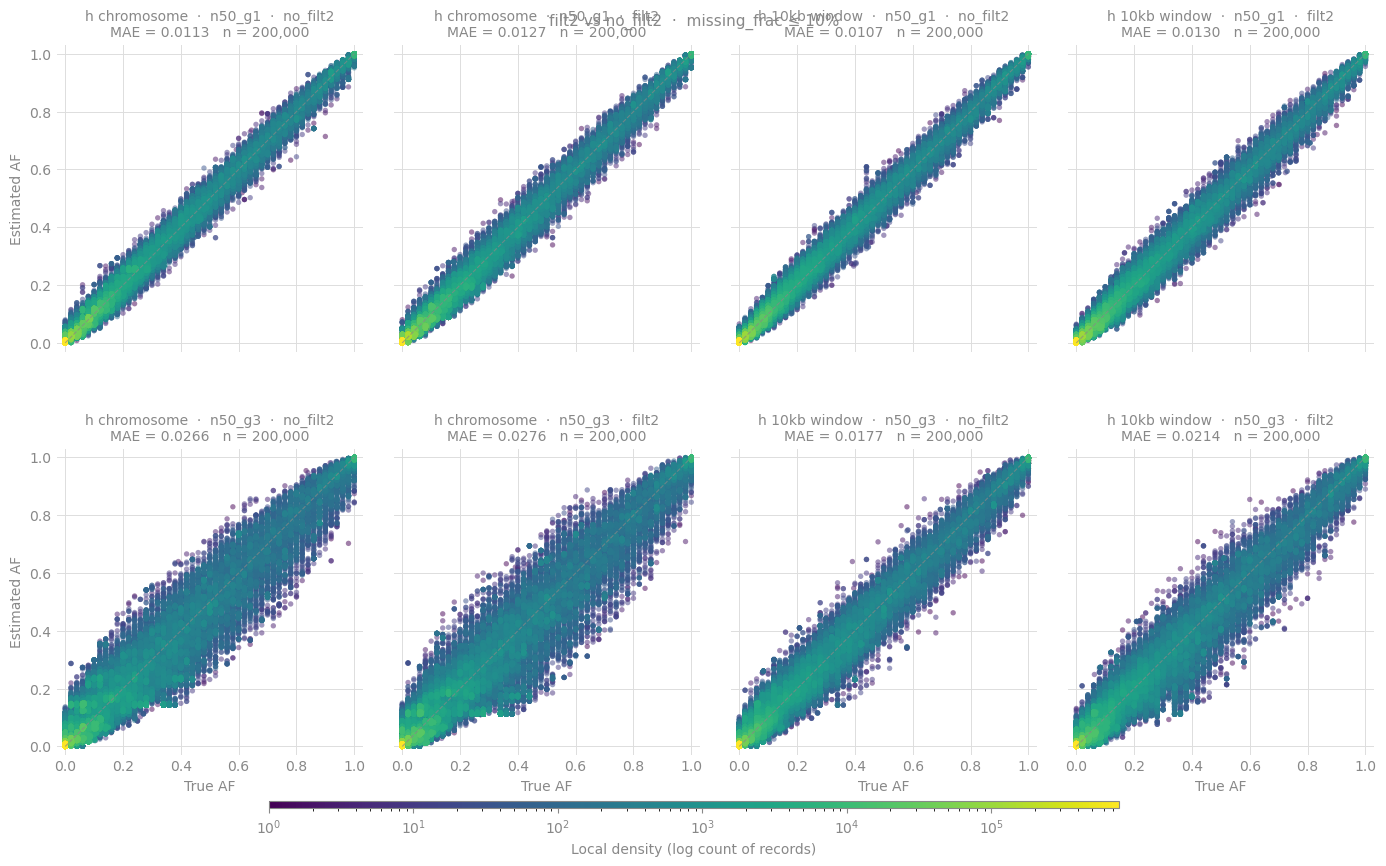

saved: plots/compare_filt2.png


In [19]:
# Scatter density grid: filt2 vs no_filt2, post missingness filter (production aesthetic).
# filt2 was only run for the original n50_g1/n50_g3 cells; restrict to those regimes.
FILT2_REGIMES = [r for r in REGIMES if r in {'n50_g1', 'n50_g3'}]
if rows_f2 and FILT2_REGIMES:
    CELL = 4.0
    col_configs = [(m, b) for m in METHODS for b in ['no_filt2', 'filt2']]  # 4 columns
    n_rows = len(FILT2_REGIMES); n_cols = len(col_configs)
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(CELL * n_cols + 1, CELL * n_rows + 0.5),
                             sharex=True, sharey=True)
    if n_rows == 1:
        axes = np.atleast_2d(axes)
    last_sm = None
    for i, regime in enumerate(FILT2_REGIMES):
        for col, (method, build) in enumerate(col_configs):
            ax = axes[i, col]
            sub = big_with_build_f[(big_with_build_f['regime']==regime) &
                                   (big_with_build_f['method']==method) &
                                   (big_with_build_f['build']==build)]
            sm = scatter_density_aesthetic(
                ax,
                sub['truth'].to_numpy(),
                sub['est'].to_numpy(),
                title=f'{METHOD_LABELS[method]}  ·  {regime}  ·  {build}',
            )
            if sm is not None:
                last_sm = sm
            if col == 0: ax.set_ylabel('Estimated AF')
            if i == n_rows - 1: ax.set_xlabel('True AF')

    fig.subplots_adjust(bottom=0.10, top=0.94, hspace=0.30, wspace=0.10)
    cbar_ax = fig.add_axes([0.25, 0.04, 0.50, 0.008])
    if last_sm is not None:
        cb = fig.colorbar(last_sm, cax=cbar_ax, orientation='horizontal',
                          label='Local density (log count of records)')
        cb.outline.set_edgecolor(GREY)
        cb.ax.xaxis.set_tick_params(color=GREY, labelcolor=GREY)
        cb.ax.xaxis.label.set_color(GREY)
    fig.suptitle(f'filt2 vs no_filt2  ·  missing_frac \u2264 {MAX_MISS*100:.0f}%',
                 y=0.975, fontsize=11, color=GREY)
    plt.savefig(PLOTS / 'compare_filt2.png', dpi=130, bbox_inches='tight')
    plt.show()
    print('saved: plots/compare_filt2.png')


## Takeaways

(populate after reading the numbers above)

- **Headline MAE** for the production-recipe (`★★` on `n50_g3`) is the key number — compare to the v3 production target (MAE 0.015 vs hapFIRE in `PIPELINE_STATE_2026-05-19.md`).
- **Per-variant-class**: SVs uniformly better than SNPs at every cell — the founder-mixture EM closes the SV-vs-SNP gap that breaks `vg call`-based pool genotyping (Wood et al. SVs R²=0.85 vs SNPs R²=0.93).
- **Missingness filter is panel-level QC**: the fan-tail at sparse-called records (denominator blow-up of `h@cn_var / h@cn_var_called`) is the same failure mode the production v3qc pipeline would have at any cactus-derived record where `CONFLICT` makes few founders callable. Worth applying as a record-level filter at production.
- **filt2 vs no_filt2**: see the A/B above. filt2 drops singleton k-mers (carrier-count<2), reducing per-founder pinning. On 80-founder cactus-only, this is a smaller effect than on the 231-panel where cactus-PG asymmetry dominates.
